Dylan Ross

Perform basic differential expression analysis (Welch's t-test) to identify top features within each block for all mutation state comparisons.

## Setup

### Imports

In [ ]:
import os
import pickle

import polars as pl
from scipy import stats
from matplotlib import pyplot as plt, rcParams

# set max font size 
rcParams["font.size"] = 7

### Constants

In [4]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures",
    "volcano"
)

# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
    "diffex"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

### Load Data

#### Utility Function: Load a mutant vs. WT comparison data subset, add ∆z and t-test p-value

In [7]:
def load_data_add_delta_z_and_ttest_p(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset, 
    adds ∆z and t-test p-value columns for the comparison of mutant vs. WT samples
    """
    # load subset sample columns
    with open(os.path.join(CACHE_DIR, f"{subset_id}_cols.pkl"), "rb") as pf:
        wt_cols, mut_cols = pickle.load(pf)

    # load subset omics data
    omics_subset = pl.read_ipc(os.path.join(CACHE_DIR, f"{subset_id}.arrow"))

    # select out the block of interest, add columns, return
    return (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
        # add the ∆z and t-test p-value columns
        .with_columns(
            (
                pl.concat_list(wt_cols)
                .list.drop_nulls()
                .alias("wt")
            ),
            (
                pl.concat_list(mut_cols)
                .list.drop_nulls()
                .alias("mut")
            ),
        )
        .with_columns(
            (
                (
                    pl.col("mut").list.mean() - pl.col("wt").list.mean()
                )
                .alias("delta_z")
            ),
            (
                pl.struct("wt", "mut")
                .map_elements(
                    lambda x: stats.ttest_ind(
                        x["wt"], 
                        x["mut"], 
                        equal_var=False  # Welch's t-test
                    ).pvalue,  # type: ignore
                    return_dtype=pl.Float64
                )
                .alias("ttest_p")
            )
        ).drop(
            "wt",
            "mut"
        )
        # correct p-values for multiple comparisons
        # Benjamini-Hochberg
        .with_columns(
            pl.col("ttest_p")
            .map_batches(
                lambda s: pl.Series(stats.false_discovery_control(s.to_numpy()))
            )
            .alias("ttest_p_adj")
        )
    )

#### Load data for all comparisons

In [8]:
comps = {
    (subset_id, block): load_data_add_delta_z_and_ttest_p(subset_id, block)
    for subset_id in [
        "B_NPM1-WT", 
        "W_NPM1-WT", 
        "B_FLT3-ITD-WT", 
        "W_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT", 
        "W_FLT3-ITDxNPM1-WT"
    ]
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics"
    ]
} | {
    (subset_id, "Acetylomics"): load_data_add_delta_z_and_ttest_p(subset_id, "Acetylomics")
    for subset_id in [
        "B_NPM1-WT", 
        "B_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT"
    ]
}

/Users/dylan.ross/Projects/AML_outcome_disparities/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_

## Volcano Plots

### Utility Functions

#### Make the volcano plot

In [9]:
def volcano_plot(
    df, 
    min_abs_delta_z, 
    max_p_value, 
    figname=None, 
    delta_z_range=None, 
    point_labels=None
) :
    def _get_color(fold_change, p_value):
        if p_value <= max_p_value:
            if fold_change >= min_abs_delta_z:
                return RED
            if fold_change <= -min_abs_delta_z:
                return BLUE
        # default color
        return GREY
    fig, ax = plt.subplots(figsize=(4, 4))
    c = [
        _get_color(dz, pv)
        for dz, pv in df.select("delta_z", "ttest_p_adj").iter_rows()
    ]
    ax.scatter(df["delta_z"], df["ttest_p_adj"], c="#00000000", marker="o", edgecolors=c, s=6, linewidths=1.)
    # add point labels if provided
    if point_labels is not None:
        for lbl, dz, pv in point_labels.iter_rows():
            ax.plot(
                [dz, dz + 0.2 if dz > 0 else dz - 0.2],
                [pv, pv],
                #c=_get_color(dz, pv),
                c="k",
                lw=0.5, 
                marker=".",
                ms=2
            )
            ax.text(
                dz + 0.15 if dz > 0 else dz - 0.15,
                pv,
                lbl,
                color=_get_color(dz, pv),
                size=6, 
                va="center",
                ha="left" if dz > 0 else "right",
                #rotation=-15 if dz > 0 else 15,
                rotation_mode="anchor", 
                bbox=dict(
                    fc="w",
                    #ec=_get_color(dz, pv),
                    ec="k",
                    lw=0.5,
                    pad=0.3
                )
            )
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(max_p_value, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(-min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(0, lw=1., c="k", zorder=-1)
    for d in ["top", "left", "right"]:
        ax.spines[d].set_visible(False)
    if delta_z_range is not None:
        ax.set_xlim(delta_z_range)
    ax.set_xlabel("∆z")
    ax.set_ylabel("adjusted p-value")
    if figname is not None:
        plt.savefig(figname, bbox_inches="tight", transparent=True, dpi=400)
    plt.show()
    plt.close()

#### Make the plot plus select out the top/bottom features

In [10]:
def plot_volcano_and_select_top_features(
    df,
    dz, 
    pv,
    subset,
    block,
    label_top_n=10,
    export_top_n=250
) : 
    # select the top up/down features
    top_up = (
        df
        .filter(
            (pl.col("ttest_p_adj") <= pv)
            & (pl.col("delta_z") >= dz)
        )
    )
    top_down = (
        df
        .filter(
            (pl.col("ttest_p_adj") <= pv)
            & (pl.col("delta_z") <= -dz)
        )
    )
    # make the plot
    volcano_plot(
        df,
        dz,
        pv,
        figname=os.path.join(
            FIGURE_DIR, 
            f"{subset}_{block}.png"
        ),
        # add text labels for the top N up and down features 
        point_labels=(
            pl.concat([
                (
                    top_up
                    .select(
                        "Feature",
                        "delta_z",
                        "ttest_p_adj"
                    )
                    .sort("ttest_p_adj")
                    .head(label_top_n)
                ),
                (
                    top_down
                    .select(
                        "Feature",
                        "delta_z",
                        "ttest_p_adj"
                    )
                    .sort("ttest_p_adj")
                    .head(label_top_n)
                ),
            ])
        )
    )
    # write top up/down features to file
    for df, up_or_down in [(top_up, "up"), (top_down, "down")]:
        if len(df) > 0:
            # write just the identified features
            (
                df
                .sort("ttest_p_adj")
                .head(export_top_n)
                .select("Feature")
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.txt"
                    ),
                    include_header=False
                )
            )
            # write the full table
            (
                df
                .sort("ttest_p_adj")
                .head(export_top_n)
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.csv"
                    ),
                )
            )
    # return the selected top up/down features (+ their full data)
    return top_up, top_down

### Make the volcano plots for selected comparisons

============ B_NPM1-WT ============
Transcriptomics


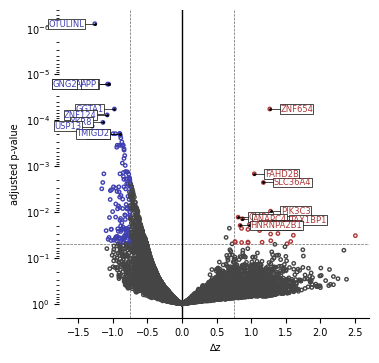

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ANAPC4""",null,-1.595616,2.549508,0.175788,-2.782017,null,0.200929,-0.139013,null,0.034589,null,-0.785694,0.34801,-0.340101,0.249953,-0.917398,2.791867,-0.124896,-0.578339,-1.128325,-1.290254,-0.220752,-1.439553,2.405581,null,-0.340728,null,null,null,null,-0.747246,1.1308,0.810742,-0.308736,-0.480964,null,…,0.863943,-0.487985,null,-0.184308,-0.735184,null,null,null,-0.701363,-0.696147,-0.361811,0.41006,0.479999,0.425293,-0.194115,null,-0.453027,-0.6337,1.43195,-0.36018,null,null,null,null,1.109289,null,null,0.787623,1.074531,0.876899,0.469454,0.353186,null,null,0.873823,0.000159,0.014108
"""CBFB""",null,-1.299322,-1.29955,1.607867,-1.525229,null,0.541329,0.488906,null,0.260636,null,-0.309232,1.483896,0.317238,0.409676,-0.535196,1.511057,-0.130598,1.531012,0.681885,0.246032,-0.92144,-0.234967,-0.708216,null,1.869266,null,null,null,null,-1.810502,0.372415,0.722821,0.44592,-1.353838,null,…,-0.15903,0.167608,null,-0.380567,0.698206,null,null,null,-1.251919,-0.756233,1.626969,-1.315829,-0.644018,-0.431273,-0.876194,null,-1.213323,-0.512984,1.691898,-1.694742,null,null,null,null,0.187006,null,null,1.080428,0.852564,0.827971,1.239756,0.413299,null,null,0.860736,0.001279,0.046314
"""IFT80""",null,-1.164345,0.381811,-0.042158,3.881008,null,-0.192074,-0.147219,null,-0.086724,null,-0.796219,-0.657916,-0.724373,-0.417353,-0.761058,1.611311,-0.454424,0.036123,-0.600833,-0.908746,-0.745699,-1.143033,0.020889,null,-0.319089,null,null,null,null,0.393889,0.77766,1.229658,-0.028049,-0.143733,null,…,-0.712053,-0.977198,null,-0.491082,1.051774,null,null,null,-0.980143,-0.899126,-1.098497,-0.464288,-0.312257,-0.676896,-0.611239,null,-0.589684,-0.744207,2.146075,-0.650127,null,null,null,null,0.281054,null,null,1.700697,0.843552,2.191939,1.472904,1.618237,null,null,1.516874,0.001415,0.049406
"""TSG101""",null,0.650574,-0.345418,-0.000962,-1.704122,null,-1.113303,-0.865096,null,0.092854,null,0.333029,-0.259428,-0.300328,1.82714,-0.369764,0.516664,-0.045663,-0.460024,-0.993955,0.139667,-0.141925,2.846418,2.161641,null,1.189835,null,null,null,null,-1.449881,-0.927,-0.72949,-0.181668,-0.718706,null,…,1.712129,-1.219298,null,-0.25024,-0.3837,null,null,null,-1.350632,-0.86098,0.723121,-0.251121,-0.471654,0.4031,-1.793487,null,-0.529167,-0.245798,0.194936,-0.311211,null,null,null,null,1.419744,null,null,0.559712,0.846149,1.976004,1.304306,0.737972,null,null,1.280319,0.000566,0.030231
"""PIK3C3""",null,-1.172481,-0.252405,0.339015,0.565867,null,-0.573748,-0.255456,null,0.444709,null,-0.809302,0.23446,0.024657,0.786146,-0.874089,1.795315,-0.923963,0.363567,-1.004032,-0.93466,-0.236777,-0.55697,3.58834,null,-0.476035,null,null,null,null,-0.736363,0.626657,1.824541,-0.53824,-0.871744,null,…,1.017579,-0.948285,null,-0.808177,0.09702,null,null,null,-1.142869,-1.202369,-0.297096,-0.254756,-0.622309,0.334853,-0.553086,null,-1.158928,-0.844886,1.655202,-0.42994,null,null,null,null,1.286948,null,null,0.740174,1.185511,1.860693,0.649002,1.11654,null,null,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MCUB""",null,1.065172,-0.418198,-0.246708,-0.652201,null,-1.247145,0.495031,null,0.618782,null,-0.646523,0.736239,0.225911,0.029019,-0.946468,2.677934,0.898552,0.170946,2.608596,0.060891,0.311312,-1.129196,-0.995128,null,-0.456792,null,null,null,null,-1.140642,-0.999883,-0.815733,1.900348,-0.071013,null,…,1.406946,-0.906663,null,-0.594937,-0.778231,null,null,null,-0.611734,0.872667,0.108321,-0.88195,1.837571,-0.301961,1.823072,null,0.557875,1.021402,1.24399,-1.151542,null,null,null,null,-0.737566,null,null,-0.489747,-0.840579,-1.384387,-0.606327,-0.510034,null,null,-0.854678,0.000356,0.023716
"""MATK""",null,-1.030829,1.69059,-0.332423,3.330042,null,1.367093,1.520024,null,0.490773,null,-0.265969,0.175988,1.993802,-0.550483,0.05749,0.632846,0.289106,0.381188,1.507522,1.307972,0.756294,-1.057507,-0.433391,null,-1.375176,null,null,null,null,0.12092,0.078896,1.732776,-0.174997,-0.488454,null,…,0.534957,-0.170925,null,-0.77339,1.171006,null,null,null,-0.849223,-0.171496,-0.152966,-0.636479,-1.620702,-1.193244,-0.482161,null,-0.546925,-1.310924,-1.343077,-1.341721,null,null,null,null,-0.409394,null,null,-0.745057,-0.95508,-0.370973,-0.595453,-1.241157,null,null,-0.807623,0.000649,0.032844
"""RPUSD1""",null,-1.422576,1.223498,-0.811592,0.828906,null,-0.009467,1.437642,null,0.057854,null,0.661066,-1.0736,1.839718,-0.755976,0.692882,1.212074,0.297989,0.005427,1.069393,-0.427239,1.147521,-1.464547,1.42475,null,-1.467345,null,null,null,null,1.294526,-0.801299,-0.180081,1.242716,0.666532,null,…,-0.683946,-0.595691,null,0.240703,0.083873,null,null,null,2.687846,0.087877,0.764125,-0.448837,0.040784,-0.0751,2.324013,null,-1.071941,-1.541173,-0.074782,-1.431151,null,null,null,null,-0.835042,null,null,-0.711898,-0.678023,-1.228431,-0.498878,-1.077221,null,null,-0.940891,0.000018,0.003577
"""TSR3""",null,-0.151508,0.074485,-0.517566,4.024491,null,-0.633472,0.884893,null,-0.310089,null,-0.251855,0.091691,0.439315,-1.035508,-0.309903,1.491089,0.811032,0.141521,1.45554,-0.225628,0.38289,-1.293053,-0.422587,null,-1.655078,null,null,null,null,0.520663,-0.599446,1.401323,1.000751,0.414654,null,…,-1.237413,0.20159,null,0.559743,1.075881,null,null,null,1.594234,0.449522,-0.574385,-1.0271,0.561669,-0.246862,0.336065,null,-0.617361,-0.39901,0.725596,-1.871403,null,null,null,null,-0.33229,null,null,-0.644337,-1.245917,-0.923295,-0.945649,-0.895305,null,null,-0.932904,0.000072,0.008571
"""ELOVL5""",null,1.044003,-0.577762,1.388269,-1.199525,null,0.207556,0.466811,null,1.178389,null,-0.410322,3.683229,0.635891,-0.087615,-0.684397,3.35188,0.093853,0.828328,0.062235,-0.855879,-0.113295,-0.731438,-0.800353,null,0.766274,null,null,null,null,-1.281348,0.040319,0.342999,0.430578,-0.110489,null,…,-1.853378,0.014082,null,-0.638712,-0.267201,null,null,null,-1.123366,0.261015,-0.890141,-0.125433,-1.034082,-0.090397,-0.615068,null,-0.30648,-0.236364,1.917399,-0.010243,null,null,null,null,-0.770824,null,null,-0.17787,-1.001896,-0.66472,-0.686567,-1.009128,n

Proteomics


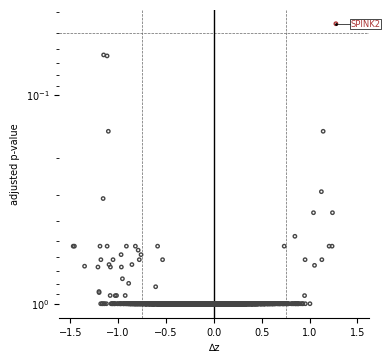

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SPINK2""",-0.503535,-0.850973,1.380731,-0.445649,null,null,null,null,null,null,-1.751147,-1.260174,-0.732149,-1.115074,-0.636832,-1.637799,0.562303,-1.780128,0.404978,0.726433,-1.63366,-1.371374,-1.181981,0.660998,-3.229552,-1.112281,-0.428988,-1.251967,0.528773,-0.321393,-1.442009,0.814478,0.470807,-1.085333,0.720564,0.74813,…,-1.025031,1.12308,0.441411,0.48384,-0.137006,0.012987,0.492411,0.958544,0.126625,-0.215594,1.006859,0.606938,-0.630369,0.943917,-0.343858,0.274494,-0.224172,-0.605924,-0.927373,0.197148,1.65476,0.915547,0.138175,1.903277,null,null,1.028053,0.771326,1.536596,1.354657,1.187043,0.657242,1.679395,0.79793,1.275426,0.000006,0.045378


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Phosphoproteomics


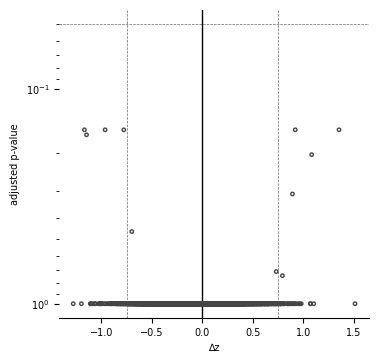

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Acetylomics


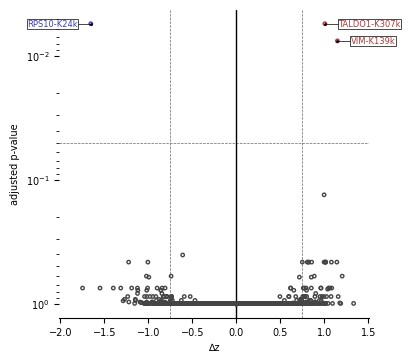

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""TALDO1-K307k""",null,null,0.047202,null,null,null,null,null,null,null,null,-0.633973,null,-0.411519,-0.389385,0.109921,-2.094795,null,null,-1.033554,-1.427985,null,-0.537828,1.358282,null,-1.902351,null,-0.869282,null,0.521655,-0.390666,null,-1.776095,1.298596,1.021267,0.691218,…,0.260968,-0.933219,null,null,0.466047,1.303128,null,-1.251814,-1.743151,-0.617218,null,0.060891,-1.175179,0.306685,-0.927915,1.107633,1.142583,-0.097331,-1.045968,null,0.734349,null,null,null,null,null,null,0.592668,1.107156,null,null,0.766882,1.065167,1.022236,1.007718,0.000004,0.005487
"""VIM-K139k""",null,null,0.58216,null,null,null,null,null,null,null,null,-0.548933,null,-0.7237,-1.503711,null,null,0.118047,-1.434041,-1.265815,-0.53082,-0.142458,null,-1.921797,-2.086777,-0.738101,0.531073,-0.759732,null,1.593615,-0.270573,-0.767944,0.120098,-0.564607,-0.025266,-0.493928,…,0.216884,0.260265,-2.839926,0.570795,0.001278,1.077082,-0.00058,0.529495,1.563955,0.897704,0.988357,-0.740841,0.624951,0.855728,0.001976,1.299825,0.674531,0.051545,0.464562,-0.566844,-0.629098,null,null,null,null,null,0.56133,1.833089,1.217885,0.655385,0.742322,1.061513,0.779311,1.163477,1.150202,0.000008,0.007555


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""RPS10-K24k""",null,null,-1.921688,null,null,null,null,null,null,null,-0.010931,-0.112461,0.322108,-0.726426,0.474139,0.80164,1.069831,-0.02367,0.032286,0.752901,0.544603,0.499314,0.422767,-0.172198,0.287016,-0.296273,-0.086941,0.480336,0.238536,-0.437944,-0.450454,0.979479,1.618129,0.103307,0.295456,1.013804,…,0.97479,1.127015,1.043325,-0.829678,1.916411,-1.925167,0.280783,1.057078,-1.232561,0.161569,-1.469311,0.263503,0.333325,-0.803171,1.180597,0.081425,-1.813872,0.10462,0.022069,-0.601255,1.569027,null,null,null,null,null,-1.096398,-1.639999,-2.654732,-1.351657,-1.062861,-1.141086,-1.547342,-1.198652,-1.653275,0.000004,0.005487


Lipidomics


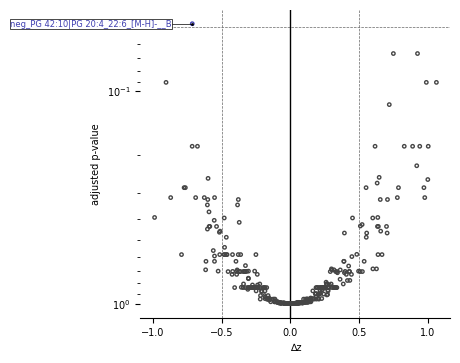

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 42:10|PG 20:4_22:6_[M-H…",0.347396,null,0.749373,null,0.512516,0.171182,-0.508622,0.030227,0.215251,-0.113265,2.378351,0.584806,null,1.587046,-0.125514,0.127634,-1.517862,1.413877,-1.734428,0.999647,0.891677,2.258667,1.458434,0.329331,2.423573,1.184204,0.197438,1.410817,0.475015,0.437931,1.056838,-0.035828,-1.01379,-1.253043,-0.118926,-0.437401,…,-1.598975,-0.435748,-1.159376,-1.196571,0.037028,-0.530015,-0.987321,-0.269791,-0.065467,-1.740659,-0.659661,0.824577,-0.593259,-1.364343,0.975402,-0.12695,0.560102,-1.803746,-0.596681,0.239507,-0.899428,null,null,null,-0.622988,-0.155464,-0.651791,-1.083093,-0.414178,-0.598413,-0.375554,-1.327171,-0.639646,-0.33922,-0.713401,0.00014,0.048112


Metabolomics


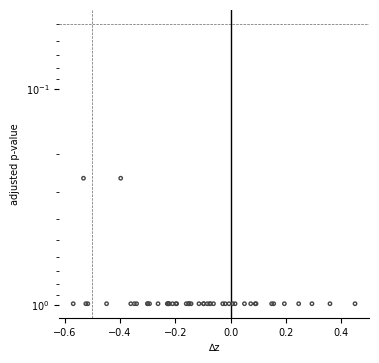

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_NPM1-WT ============
Transcriptomics


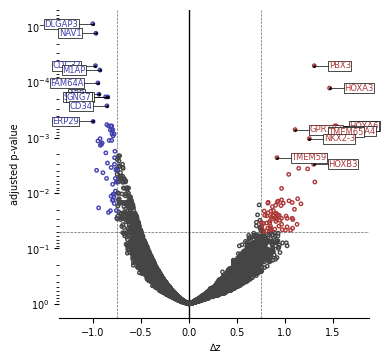

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""GDE1""",null,0.752159,null,0.239327,-1.333929,null,1.271917,-0.308497,-0.010203,0.529415,-1.827138,-1.044539,-0.052167,-0.850695,2.687378,-0.081101,-0.923516,-0.495358,null,-1.995396,-0.875364,null,null,1.158227,-0.845342,-0.558815,-0.750991,null,0.540053,-0.736022,-0.154408,0.555953,-0.096565,-0.573011,-1.110077,null,…,-0.290778,0.385797,1.176478,-0.278235,-0.305938,0.375886,-0.748963,0.544902,0.33544,null,1.578229,null,0.346151,null,0.480357,null,null,2.477082,1.155676,0.789723,1.951945,1.635547,null,-0.264095,null,0.979517,0.4482,1.686914,-0.384073,0.15071,-0.029875,0.642958,null,null,0.824345,0.000133,0.014724
"""RUFY3""",null,0.479429,null,0.044723,-1.190876,null,0.941423,-0.130974,-0.508654,1.030838,-0.176473,1.480891,-1.602008,-0.425567,-0.699068,-0.691423,-1.477564,-0.419389,null,-0.785177,-0.266658,null,null,-0.358593,-1.012537,-1.248999,-0.881283,null,-0.663696,1.00859,-0.315703,-0.130473,-0.864527,-0.022928,0.499204,null,…,-0.206187,-0.128729,0.571899,-0.550714,-0.253482,0.629053,0.780822,0.251295,1.093829,null,2.918928,null,0.696187,null,-0.429815,null,null,0.858575,2.799384,1.268379,-0.130027,0.756941,null,-0.082995,null,-0.256705,-0.005453,0.21003,3.181628,-0.557133,0.473179,1.510303,null,null,0.911218,0.000323,0.023562
"""CHPF2""",null,0.163,null,0.559633,-0.600811,null,2.012954,0.305875,-0.678446,0.456216,-0.328563,0.248483,-1.54053,0.271408,-0.483496,0.607022,0.570812,-0.290238,null,-0.534031,-0.122512,null,null,1.806907,0.645132,-0.4987,-0.98582,null,-1.231211,-0.192369,-0.88273,-0.888315,-0.080103,-0.117415,0.011223,null,…,0.943086,0.374463,2.820981,0.896461,1.030634,1.897672,0.787673,-0.004438,1.468987,null,-0.253759,null,0.628894,null,-0.332365,null,null,2.338366,-0.23514,0.781417,-1.107674,2.035653,null,-0.392981,null,0.677694,0.661263,0.083343,1.582482,0.304961,-0.32653,0.987865,null,null,0.964084,0.000053,0.008257
"""PHKA2""",null,-0.31156,null,-0.337469,-0.218769,null,-0.085278,0.04649,0.089985,-0.730207,-0.781207,-0.815144,-1.536903,-0.861522,0.339612,-0.789912,-0.646094,-1.469732,null,0.379629,-0.684463,null,null,-0.722482,-0.592327,1.628883,1.925047,null,-0.824123,-0.132902,-0.13845,-0.398786,0.190005,-0.522655,-0.482211,null,…,1.082648,1.00713,0.176371,0.972164,1.004671,1.490331,1.011954,0.220619,2.375761,null,1.428102,null,0.134811,null,-0.798312,null,null,-0.455763,-0.022662,2.844647,-1.127987,-0.824042,null,0.557263,null,-1.30341,-0.555485,-0.465988,2.782253,1.109244,1.75575,1.27823,null,null,0.961896,0.00049,0.028727
"""KATNIP""",null,0.667901,null,0.248852,-0.926686,null,-0.194366,-0.565746,-0.380492,-0.281764,-1.633158,1.067306,-0.842492,-0.860624,1.076703,1.828185,0.077494,-1.586679,null,-1.111819,-0.9155,null,null,0.0201,-0.955303,0.949951,0.771303,null,-1.145444,0.714017,-0.324096,-1.260326,-0.614542,0.629531,-0.669719,null,…,0.936097,0.767058,1.483969,0.356288,0.430655,-0.656816,1.037193,0.670105,2.15934,null,0.763122,null,1.301362,null,-1.065599,null,null,1.442301,1.283774,2.841238,-1.021741,0.922538,null,0.842576,null,0.05

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD133""",null,-0.789805,null,1.388163,-0.737406,null,-0.784391,-0.09336,-0.103397,-0.304368,1.461359,1.073347,-0.788044,-0.180067,-0.788551,0.274614,-0.599275,-0.45654,null,-0.408394,-0.741712,null,null,0.784267,2.130976,-0.787187,-0.787976,null,-0.769808,1.072043,1.117609,-0.426047,-0.353273,0.620907,0.625077,null,…,0.11144,-0.450069,0.069111,-0.764901,-0.423899,-0.769658,-0.158715,-0.163652,-0.787751,null,-0.785909,null,-0.785339,null,-0.667123,null,null,-0.74637,-0.785592,-0.782732,-0.088855,-0.731631,null,-0.59008,null,-0.330453,-0.788323,-0.550547,-0.785455,-0.769299,-0.776515,-0.728463,null,null,-0.805035,7.7152e-7,0.000616
"""ELOVL5""",null,1.020658,null,1.77175,1.12318,null,0.395814,0.657666,1.764338,-0.129578,0.299825,-1.203816,-1.49115,-0.237753,-0.073522,0.837791,2.135597,-0.269048,null,2.174898,0.553883,null,null,2.930477,0.374473,0.801574,0.53041,null,-0.317143,-0.306787,-0.442767,0.240883,1.209595,-0.055096,-0.833745,null,…,-0.003432,-1.741928,-2.491942,0.506372,-0.680084,-1.6003,0.12111,-0.368673,-0.827024,null,-1.23791,null,-0.417907,null,1.342858,null,null,-1.418156,0.22509,-0.727073,-1.746342,-0.868946,null,0.04363,null,-0.321611,-0.215182,0.665818,-2.011763,-0.166912,-0.44162,-1.321588,null,null,-0.839446,0.000288,0.022488
"""CNN2""",null,-1.587074,null,0.089843,1.348678,null,0.717894,2.023579,1.23521,1.964519,1.217009,-1.309884,0.187844,0.220147,-1.351418,0.719436,1.369924,-0.107358,null,1.026545,3.155827,null,null,1.070001,-0.369994,-0.110421,-0.478815,null,-1.188373,-0.164723,-0.237547,0.321765,1.223242,0.559824,-0.577627,null,…,-0.123623,-1.207421,-1.325475,-0.284881,-1.200048,-0.75792,-1.054818,0.042043,-0.52111,null,0.063454,null,-0.978487,null,-0.589035,null,null,-1.8863,1.097544,-1.155023,-1.943366,-0.30179,null,-0.470721,null,-0.454923,-0.632298,0.376973,-0.954279,0.006263,-0.737927,-1.105916,null,null,-0.923615,0.000003,0.001375
"""ARHGAP10""",null,0.819332,null,-0.131753,-0.311002,null,1.832339,-0.319012,-0.204472,0.687396,3.171402,-1.0651,-1.057095,-0.001433,1.555228,0.213884,-0.788284,0.931412,null,-0.06671,-0.871741,null,null,-0.200705,0.905808,-0.542453,0.215359,null,-0.727501,-0.690557,-0.640603,0.307897,-0.199336,0.869691,-0.4602,null,…,-0.777718,-0.661814,-1.294383,-0.532155,-0.307264,-0.352807,0.44475,-0.474021,-0.694759,null,-1.284831,null,-1.231509,null,-0.086672,null,null,-1.257814,-1.157624,0.167122,-1.250462,-1.023357,null,-0.558068,null,0.97105,-0.356419,-0.706351,0.602165,-0.603507,-0.59941,0.189463,null,null,-0.767235,0.000061,0.009242
"""ERP29""",null,2.613654,null,0.400529,0.712288,null,-0.589051,1.551646,0.311941,-0.229149,-0.255258,-1.227193,1.462217,0.638809,0.198165,-0.118142,-0.382349,-0.622056,null,0.202686,-0.006847,null,null,-0.860655,-0.216879,0.878856,2.174254,null,0.638599,1.377317,0.532055,3.034639,1.498939,0.264849,1.355581,null,…,-0.440177,0.740355,0.188757,-0.224877,-0.850086,-0.90675,-0.249468,0.032933,-1.322718,null,-1.039679,null,-0.795473,null,0.161898,null,null,-1.559955,0.162295,-1.29515,-1.4252

Proteomics


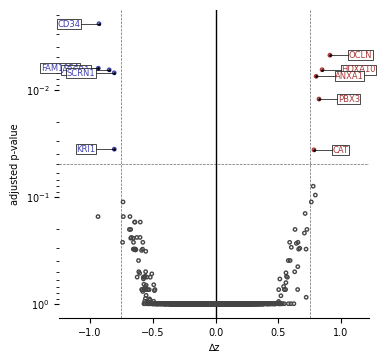

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ANXA1""",-0.06518,-0.344929,0.957281,-2.142164,-0.211283,-0.536254,-2.376397,-0.702281,0.122102,0.954419,-1.233053,0.106148,-0.827532,-0.636065,0.042115,-0.512114,-1.188125,0.399051,0.828426,0.848993,-0.36088,-1.109749,0.343915,-1.112489,-0.025598,-0.298367,-0.575521,1.024904,1.618668,0.839303,-2.293753,1.065981,0.135978,1.193013,0.248645,-0.29844,…,1.643098,0.516196,0.731983,1.327557,-0.074011,0.533037,1.056968,0.417164,0.665714,0.378209,0.109387,0.885557,-0.491742,0.787898,-1.279781,-1.122118,-1.033414,1.532681,0.302567,1.813539,0.933288,0.547609,0.579914,1.398247,-0.180167,1.373133,0.654171,0.904882,1.393722,0.426171,0.342455,0.003081,0.160395,0.391571,0.801813,0.000007,0.007499
"""CAT""",-0.423944,-0.6678,1.072218,-0.244101,-0.234633,-1.178206,-1.680806,-0.91465,0.139921,-0.082387,1.494574,-0.810874,-0.599857,-1.450283,0.835518,-0.335889,-0.945578,-0.881011,0.536864,0.525065,-0.549184,0.013291,-0.7464,-1.178636,-0.189561,-0.700774,0.24812,0.252884,0.321961,1.063116,-2.033087,0.643859,-0.565536,-0.590023,0.958376,-0.799621,…,1.64963,0.060477,0.594352,-0.461571,0.172559,1.633248,1.683641,1.347437,0.479075,1.020049,1.087169,1.452558,0.149463,-0.493388,-1.219974,-1.486797,-0.76907,-0.343446,0.403043,1.983556,0.731356,0.294963,1.37092,1.243383,0.035392,-0.134393,-0.116541,0.849301,1.850738,1.15312,0.76802,0.913613,0.500087,-0.657365,0.784401,0.000045,0.036493
"""HOXA10""",-0.387213,0.07209,0.659633,-1.314581,-0.988098,-0.801455,-1.586178,-2.425386,-0.829796,0.259314,-0.06804,-0.467303,2.078631,-0.738372,1.149263,-0.040391,-1.001248,-0.580486,1.16485,-0.127275,-0.979191,-0.220558,-1.013267,-1.138292,-0.389954,0.331606,1.327445,-0.373015,0.361471,0.353509,-0.973056,-0.29207,-1.338294,-0.617186,1.001703,-1.160753,…,1.76939,0.860429,0.872002,0.498162,0.660118,1.247227,0.966878,1.021805,0.008117,0.975821,0.836928,1.557542,0.30964,1.362033,-1.518035,-1.065922,-1.44863,0.777999,0.628903,1.636694,1.116071,0.685622,0.698803,1.144252,0.171696,0.053809,0.200648,0.500567,1.028154,0.203387,0.951279,0.714608,0.954298,-0.869418,0.849477,0.000003,0.006506
"""OCLN""",-0.159867,0.962558,0.681898,-0.803189,-0.426296,-1.223587,-1.762581,-1.412321,-0.213394,0.123824,-0.676777,-0.10889,-0.420718,-0.943573,-0.191674,0.372629,-0.692399,-0.886609,0.330778,1.133348,-0.604541,0.681282,-0.813573,-0.675522,-0.415518,-0.216221,-0.871994,1.499071,0.30077,0.229489,0.544464,0.64865,-1.242241,0.003782,-0.308909,-1.357765,…,1.734694,1.343616,1.200633,1.14898,0.814778,1.264605,1.087803,1.488191,-0.527302,1.096167,0.00106,0.731723,0.01868,0.137224,-1.480432,-1.523269,-0.478722,1.078125,-0.176811,1.726335,1.148918,0.788841,0.947591,0.67635,1.011008,-0.006414,0.185581,0.718698,1.96722,0.855508,0.773237,1.053282,0.199767,-0.351717,0.91182,0.000001,0.004761
"""PBX3""",0.058453,0.21351,0.579469,-1.323673,-0.841841,-1.220034,-1.685682,-1.795223,-0.71716,0.539767,-0.166776,-0.334409,0.120353,-0.431768,1.572734,-0.933156,-3.229354,0.173925,1.114992,0.491064,-0.652609,-0.616627,-0.050482,-1.167755,-0.351146,1

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",1.242199,-0.276604,0.014818,0.496685,-0.197465,1.229728,-1.661001,-1.696032,-0.458131,0.990262,1.8688,0.032781,-0.069056,-0.205078,-0.871001,1.724275,null,-0.186125,0.054304,-0.090675,0.05239,-0.15966,1.065066,0.561542,1.9261,-0.607947,0.890605,-0.532857,0.112266,0.578762,-1.51821,0.709689,-0.413098,1.391581,-0.226516,1.103121,…,0.026922,-0.210375,-0.710001,-1.000752,-0.71029,-0.745064,-0.313236,-0.435649,-1.403031,-1.365115,-0.845604,-1.32168,-1.806276,0.404541,-2.332196,-1.310893,-1.784774,null,null,-0.365148,null,0.285544,null,-0.301275,-0.78542,0.384381,0.330848,0.44957,-0.79798,-0.555623,-0.93005,-0.433353,0.064151,-0.145416,-0.847563,0.000004,0.006525
"""CD34""",0.591847,-0.62821,0.498394,-0.372036,-0.527873,-0.532693,-0.716059,-0.923339,-0.289619,1.100623,2.327547,0.4434,-0.375518,0.63433,1.116936,0.557454,-1.155203,1.00783,-0.308689,0.122163,-0.762518,1.046084,1.926133,-0.410361,1.715835,-0.759709,-0.508517,1.302208,-0.492482,0.21516,1.002483,0.810046,-1.191224,1.397996,0.806277,0.60573,…,-0.535005,-0.202552,-1.18699,-1.124834,-0.109731,-1.622633,-0.432134,0.129017,-1.261608,-0.405657,-0.989683,-1.265107,-1.221464,-0.423185,-1.346289,-1.423904,-1.528572,1.081948,-0.504116,-0.531606,0.680005,-0.507793,-0.887468,-0.730903,-1.198144,1.609713,-0.067172,-0.38933,-1.190245,-0.846669,-1.131343,-1.191895,-1.154243,0.756959,-0.928947,3.0010e-7,0.002419
"""FAM105A""",-0.494798,2.057282,1.247373,-0.660878,1.533807,0.502911,-1.811543,0.175023,-0.248358,2.054403,0.57404,1.123748,1.457044,0.862467,-1.103679,0.684849,0.134016,0.403373,0.818469,1.264498,0.670469,-0.748925,0.193901,-0.678864,0.084069,-0.704656,-0.439178,2.162671,1.031272,-0.638331,-1.011662,0.898104,-0.340339,1.185345,-0.041527,-0.454928,…,-0.334278,0.388975,-1.366694,-0.58156,-1.202266,-1.737808,-0.440769,0.210238,-1.851119,-0.593959,-1.307941,-2.114364,-1.731917,0.941485,-0.701082,-1.592332,-0.931266,-0.622159,-0.38216,-0.973176,-1.195901,0.276196,-0.554686,-0.08086,-1.513751,1.192728,0.860024,0.662315,-1.336824,-0.880634,-1.080361,-1.366177,-1.655343,0.81784,-0.934279,0.000002,0.006302
"""KRI1""",0.0865,1.077239,0.727734,0.449319,0.180147,-0.54593,-1.774595,-1.974748,-0.679144,1.612024,1.586768,-0.008316,1.101295,0.083973,1.464851,0.001724,-2.022985,0.250627,0.775015,0.353238,-0.786512,0.194041,1.759359,1.47583,1.149989,0.505993,1.229764,-0.094902,1.381146,0.342975,-1.068983,0.705872,-2.108692,0.328278,0.576776,-0.850432,…,0.489079,0.039639,-0.545388,-0.88656,-1.181772,-1.490002,-0.098584,0.070079,-1.600346,-1.55325,-1.7648,-1.096658,-2.002994,0.029325,-1.326991,-2.420697,-1.802006,0.781626,0.79421,-0.716055,-0.059629,-0.714081,-0.44606,-0.620718,-1.729377,0.947951,1.265347,0.115878,-0.369787,-0.572886,-0.444857,-1.145242,0.214244,0.109297,-0.80684,0.00004,0.035968
"""SCRN1""",1.022157,-0.147366,1.686112,-1.495014,-0.747394,-0.109782,-1.865413,-2.288663,0.20733,0.163601,1.800445,-0.424886,-0.550798,-0.79536,-0.371214,0.791373,0.313772,0.074697,0.569097,1.177848,0.002273,0.894077,-0.491117,-1.3

Phosphoproteomics


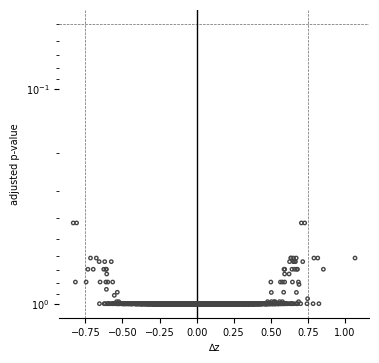

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Lipidomics


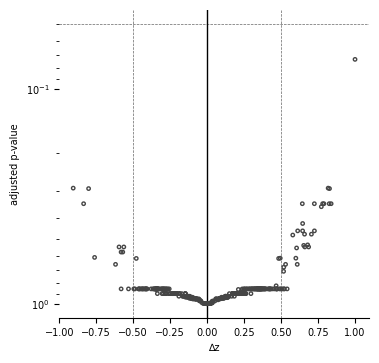

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Metabolomics


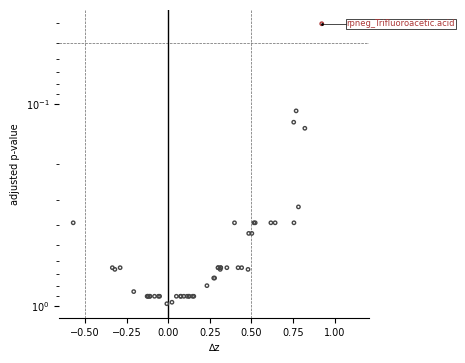

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rpneg_Trifluoroacetic.acid""",-0.645465,-1.850586,-0.508841,-1.646591,-0.534271,-0.378969,0.497714,1.494652,-0.403837,-0.598273,1.798179,0.090629,-0.738507,-0.676306,-0.437854,0.227053,0.42522,0.828664,-2.248674,-0.662264,-0.415972,null,1.7346,0.61742,-0.760872,0.129687,-1.415675,null,null,null,0.42451,null,null,null,null,null,…,0.7277,0.323701,1.207484,0.082876,0.666556,-0.721928,1.958211,0.363959,0.875863,null,null,null,null,null,null,null,null,null,0.03112,null,null,null,null,null,null,0.138941,null,null,null,1.040037,null,null,null,null,0.922194,0.00082,0.040158


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITD-WT ============
Transcriptomics


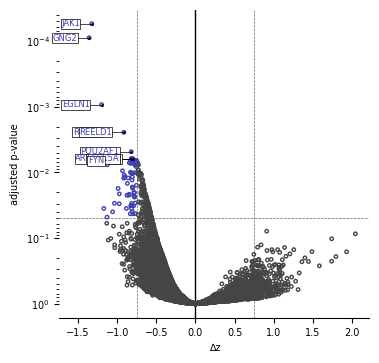

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""FYN""",null,0.278498,-0.72437,-0.129364,3.53074,null,-0.936397,-1.151613,null,-0.604853,null,0.620101,0.311464,2.058116,1.115029,-0.141926,1.039696,-1.004165,-0.765355,-0.598767,-0.386992,2.522597,0.641346,0.006759,null,0.009028,null,null,null,null,-0.309465,-0.879477,0.135152,-0.736588,-0.001998,null,…,0.008975,null,0.430121,0.96965,null,null,null,0.583247,0.251692,0.414688,-0.609784,0.376801,0.121353,-0.964941,null,-1.107367,1.288023,1.304929,-0.875304,null,null,-1.049085,-1.337171,null,null,-0.780936,null,-0.558007,-1.31748,-0.228705,-0.857929,null,-1.116262,-0.504117,-1.019234,0.000008,0.006609
"""ARHGAP31""",null,0.37629,-0.35515,1.034283,-0.788517,null,-0.247754,-0.669469,null,-0.515415,null,-0.658797,-0.520082,-0.481398,1.828988,-0.677783,2.333807,0.230601,-0.730649,-0.36715,-0.814918,-0.095669,-0.7405,-0.660397,null,-0.47699,null,null,null,null,-0.602545,-0.700013,1.367895,-0.527579,0.344176,null,…,3.131174,null,0.320235,0.04187,null,null,null,1.336491,0.556435,-0.63991,-0.612344,1.947106,-0.744584,3.194299,null,-0.179484,1.99577,0.778291,0.015875,null,null,-0.614344,-0.702434,null,null,-0.591408,null,-0.845264,-0.747255,-0.661321,-0.583395,null,-0.81351,-0.533704,-0.801299,0.000003,0.006162
"""PDZD4""",null,0.078208,-0.407218,-0.372154,1.597747,null,-0.254746,1.026433,null,-0.452934,null,1.687775,-0.769497,2.481979,-0.120665,0.433031,-0.373847,-0.816544,-0.359717,-0.656625,2.159779,0.179596,-0.53043,-0.433354,null,-0.620231,null,null,null,null,0.044363,-0.716401,0.45799,3.910938,-0.494608,null,…,-0.667351,null,0.1487,0.19594,null,null,null,-0.704971,1.772148,-0.578202,-0.716787,-0.570493,-0.334298,-0.493705,null,-0.884965,0.740584,-0.653956,2.125734,null,null,-0.791337,-0.599771,null,null,-0.453125,null,-0.801209,-0.629457,-0.597345,-0.612835,null,-0.77803,-0.755714,-0.791591,0.000005,0.006609
"""MEF2A""",null,-0.414762,1.864698,0.73056,0.531405,null,0.768912,-0.388788,null,0.158749,null,-0.815001,0.585159,-0.191152,1.19329,-0.796672,4.343742,0.619699,-0.288427,1.306133,-1.460748,1.383739,-0.472227,-0.409009,null,-0.498133,null,null,null,null,0.241157,0.249079,1.313078,-0.779022,2.152459,null,…,0.418142,null,-0.923688,-0.762993,null,null,null,-0.500516,-1.182771,-0.132305,0.598261,-0.717472,-0.109053,0.002996,null,0.564621,-0.248092,0.81208,-0.761515,null,null,-1.345395,-0.868456,null,null,-0.545695,null,-0.847418,-0.46033,-0.223686,-0.219293,null,-1.22159,-0.74609,-0.851976,0.000158,0.022203
"""LRP6""",null,-0.636388,3.63322,-0.27733,-0.69587,null,-0.443812,-0.041777,null,-0.664909,null,-0.44882,-0.663883,0.709301,1.269535,1.049455,-0.596756,1.256737,1.152366,-0.370589,0.261283,1.737632,0.358301,-0.564508,null,-0.668851,null,null,null,null,1.410103,-0.621156,-0.596383,-0.671534,1.259974,null,…,-0.684149,null,-0.67467,0.591014,null,null,null,-0.093197,-0.634215,-0.625368,3.329453,-0.66538,-0.661894,0.176657,null,-0.446105,-0.656773,0.318163,0.385149,null,null,-0.690137,-0.572622,null,null,-0.693667,null,

Proteomics


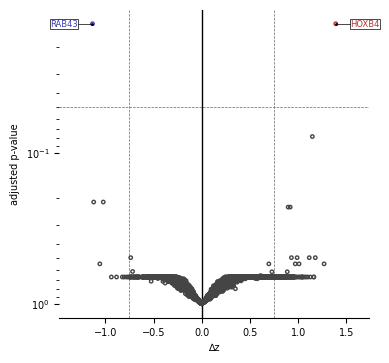

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HOXB4""",-1.446912,-0.64912,0.172565,-1.310122,null,null,null,null,null,null,-0.01902,null,0.398113,-0.175795,-0.169887,-1.91284,-0.398695,0.354508,-0.637851,-0.610786,-1.437641,0.624904,-0.20397,-0.580591,0.009946,-2.85185,0.365672,0.376835,0.872165,null,0.737053,-0.093186,null,-0.210506,1.192887,null,…,-0.37009,0.849761,-1.880761,-1.128066,-0.261725,-0.538646,1.671368,-1.171695,null,-0.01809,-0.266302,null,0.803318,0.061483,null,-1.082221,null,-0.14104,-0.644475,-1.01569,0.84546,1.515559,null,null,0.597648,2.132101,1.006219,0.922691,1.395163,0.106519,1.587351,1.251413,null,1.206804,1.389211,0.000003,0.013991


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""RAB43""",-0.159761,1.329425,0.277425,0.631404,null,null,null,null,null,null,-1.322862,-0.602332,0.388543,-0.513547,-0.035921,-1.32233,-0.396362,0.559977,-1.520188,-1.806718,0.379933,0.889388,-0.240202,-2.832068,-0.101946,0.03074,0.584422,1.031422,-1.404129,1.167011,1.404267,-0.047895,-1.002194,-0.263474,1.91632,1.500762,…,0.66833,-1.646132,-0.423647,-0.434556,1.306611,-0.514577,0.583777,1.53077,1.373107,-0.73337,0.52974,0.881965,-1.436538,1.017123,0.793996,1.252173,0.783103,0.76111,-0.393592,-0.332959,-0.396875,-0.725187,null,-1.729761,-1.200111,-0.639488,-1.22569,-1.197634,-1.228136,-0.435154,-0.620863,-1.027173,-1.570265,0.124375,-1.132797,0.000002,0.013991


Phosphoproteomics


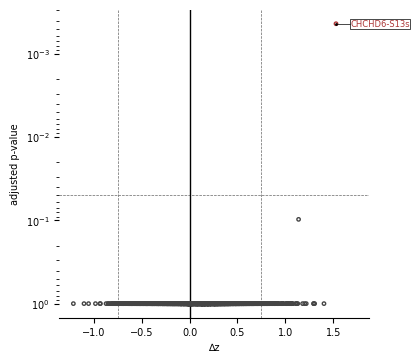

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CHCHD6-S13s""",null,-0.012752,null,-0.20849,null,null,null,null,null,null,null,-1.197718,-2.124969,null,-1.46366,-2.437028,-1.075302,null,-0.400079,0.528811,null,0.145937,0.309665,null,0.100358,0.238216,null,null,null,0.202771,-0.148621,-0.214726,-0.79525,null,null,-1.151013,…,-0.089393,0.572872,null,null,-0.632014,-0.7594,null,null,0.595973,0.720733,null,-0.100513,-0.052345,0.567328,1.22627,null,0.034563,0.340031,-1.409364,null,-2.202594,null,null,1.173022,null,1.342826,null,null,1.640665,null,null,1.691342,0.86973,1.276331,1.527293,5.1734e-8,0.000433


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Acetylomics


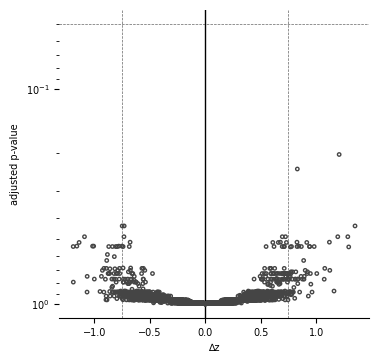

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Lipidomics


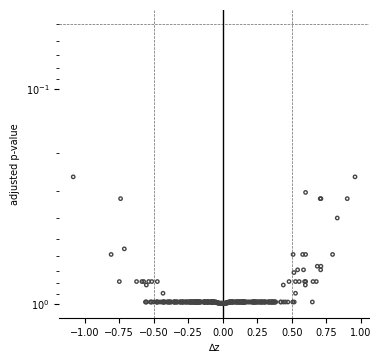

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Metabolomics


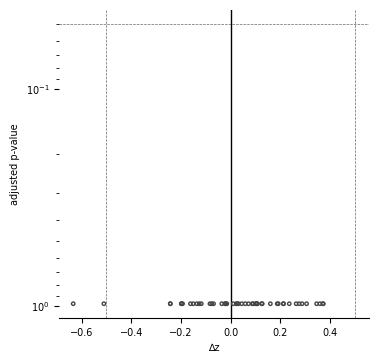

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITD-WT ============
Transcriptomics


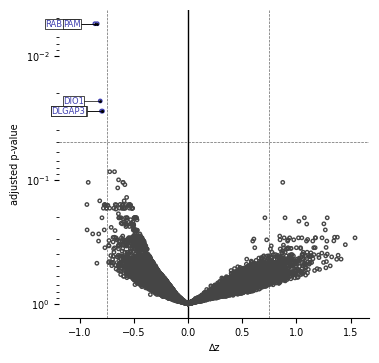

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NEDD4L""",null,2.401289,null,-0.774281,2.411114,null,-0.382207,-0.71407,0.191302,-0.905534,-0.36536,-0.639582,-0.713055,-0.520711,-0.233647,1.352755,0.073138,0.669687,null,0.880262,0.078061,null,null,-0.906439,-0.185228,3.152248,2.371409,null,-0.813637,-0.897857,-0.630711,1.66099,0.884892,-0.789418,-0.895083,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.951953,null,null,-0.717164,0.207773,-1.000523,-0.894597,null,null,-0.767169,-0.838075,0.031355,-0.409981,null,null,-0.875833,-0.761742,-0.618055,-0.889323,-0.565965,null,null,null,-0.790189,0.00001,0.027965
"""DLGAP3""",null,-0.83219,null,-0.833915,-0.789657,null,-1.00003,0.975695,0.664008,-0.108439,1.295925,-0.754672,-0.424177,0.114935,-0.77245,-0.476723,-0.424457,-0.614472,null,-0.439108,-0.685887,null,null,-1.009859,-0.899916,1.203397,-0.853262,null,0.686971,-0.932054,0.477531,2.606447,0.102908,0.691189,-0.812877,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.452123,null,null,-0.718359,-0.124356,-0.953751,-0.762371,null,null,-0.99611,-0.789132,-0.461944,0.333559,null,null,-0.843202,-0.724927,-0.995574,-0.77813,-0.887128,null,null,null,-0.799119,0.00001,0.027965
"""RAB33A""",null,-0.087481,null,1.000969,-0.515209,null,-0.704628,-0.455957,-0.257693,-0.253956,0.764765,-0.917695,-0.561213,-0.426682,1.632914,-0.034179,-0.341857,-0.292137,null,0.007504,-0.789701,null,null,2.085643,0.446091,1.777344,0.183359,null,-0.343222,-0.659146,-0.618242,-0.574599,0.286225,-0.236594,-1.002894,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.990318,null,null,-0.407213,-0.46818,-1.008715,-0.736072,null,null,-0.989199,-0.969635,-0.343331,-0.873326,null,null,-0.501832,-0.683627,-0.041703,-0.981939,-0.861653,null,null,null,-0.860509,4.5241e-7,0.005521
"""PAM""",null,-0.795986,null,-0.18835,-0.124878,null,-0.066011,0.539356,-0.382552,0.173998,-1.066987,1.639817,-1.083069,0.336075,-0.04271,-0.254564,-0.40518,0.10948,null,0.140157,-0.470393,null,null,-0.626918,0.97987,-1.077262,-1.037915,null,2.543325,-0.784145,2.829581,-0.323581,1.91067,1.364619,-0.672828,null,…,null,null,null,null,null,null,null,null,null,null,null,0.021205,null,null,-0.421257,-0.883074,-0.84007,-0.848392,null,null,-1.034284,-0.839966,-0.646011,-0.639351,null,null,-0.763263,-0.930571,-0.172414,-0.906829,-0.702861,null,null,null,-0.838718,7.6835e-7,0.005521
"""DIO1""",null,2.122833,null,1.136037,-0.793175,null,-0.793175,-0.793175,1.495568,-0.092815,-0.237921,-0.793175,1.314804,-0.793175,1.908678,-0.793175,-0.793175,-0.356523,null,-0.793175,-0.793175,null,null,-0.793175,1.289652,1.556762,-0.490103,null,-0.520548,-0.441259,1.928193,1.487205,-0.793175,-0.351826,0.238185,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.209187,null,null,-0.793175,-0.793175,-0.793175,-0.793175,null,null,-0.793175,-0.793175,-0.793175,-0.793175,null,null,-0.793175,-0.793175,-0.793175,0.438585,-0.793175,null,null,null,-0.810918,0.000005,0.023174


Proteomics


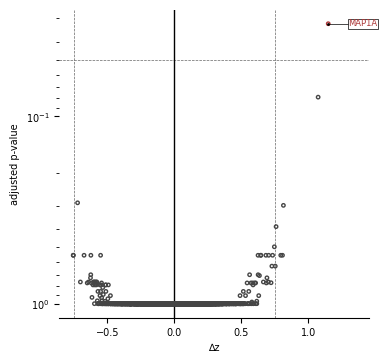

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MAP1A""",0.633355,-0.339799,1.090892,-1.236583,-0.097987,0.26325,-1.813366,-1.849559,-0.803396,0.124168,-0.652482,0.564114,0.285845,-0.708258,-0.727359,0.309815,-1.38643,-0.242974,-0.345779,-0.185391,-0.786984,-0.157175,0.953711,0.069562,-0.559414,-0.419188,-0.84552,1.920235,-0.112875,0.65075,-1.267476,-0.471019,-1.418145,-0.438048,-0.092023,0.641176,…,-0.822271,0.518718,-0.16952,1.68724,-0.027286,1.618157,0.066699,-0.797727,0.261376,1.49064,1.872314,-1.175404,1.821909,1.179129,-0.158503,-0.263735,0.020873,1.258831,0.597997,-0.332167,2.395393,1.975347,0.712186,1.799435,1.95608,-0.965317,1.882735,-0.595293,1.056613,2.255789,1.1399,-0.320885,2.884403,0.548109,1.148885,0.000004,0.031997


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Phosphoproteomics


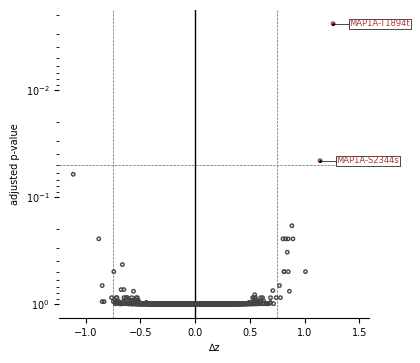

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MAP1A-S2344s""",0.698441,-1.068014,null,-1.15919,null,-0.511602,null,null,null,0.399899,-0.497607,0.716267,null,-1.07033,-0.5341,0.206928,-2.224235,null,-0.780529,0.169932,null,null,1.004023,0.226136,-0.632175,-1.142962,-1.29135,1.248477,-0.586969,0.993379,-0.377614,null,null,null,null,0.27089,…,-0.977157,1.379907,-0.67982,1.435172,-1.122287,1.57833,null,-0.756917,null,0.956653,1.856446,null,1.159594,0.829671,-0.279812,null,0.635744,0.560245,null,0.085832,1.979641,null,0.657893,1.446198,1.873166,-0.919726,1.685316,-0.758764,1.503202,1.931792,0.93195,-0.281348,2.012694,0.614034,1.14122,0.000011,0.046025
"""MAP1A-T1894t""",0.294072,-1.162689,null,null,null,-0.505297,null,null,-1.259408,-0.385927,-0.650891,null,null,-1.119466,-0.201079,null,-2.038406,null,null,-1.522688,null,null,null,0.287656,-0.326317,null,-0.86966,1.227597,-0.976675,null,-0.649067,null,null,-0.556199,null,0.846504,…,-0.923882,1.29686,0.128327,0.938594,null,1.394028,null,null,0.189889,0.996199,1.902008,-0.727713,0.723559,1.255575,-0.206493,null,0.187488,0.96877,1.32703,0.965782,2.553886,null,0.09195,1.464861,1.704587,-0.669073,1.810739,-0.283579,1.537961,1.052784,0.873593,-0.92023,1.741417,0.070435,1.260846,2.8849e-7,0.002412


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Lipidomics


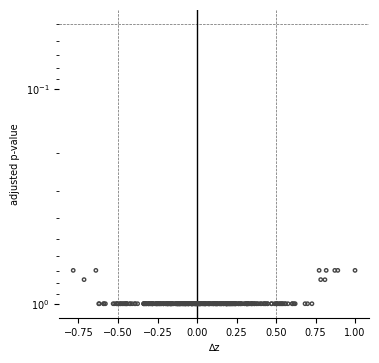

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Metabolomics


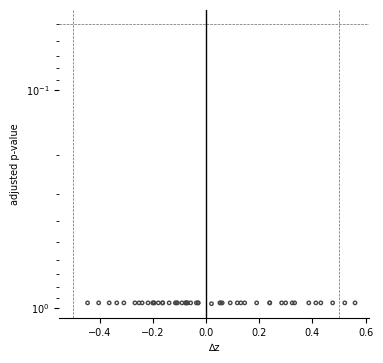

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITDxNPM1-WT ============
Transcriptomics


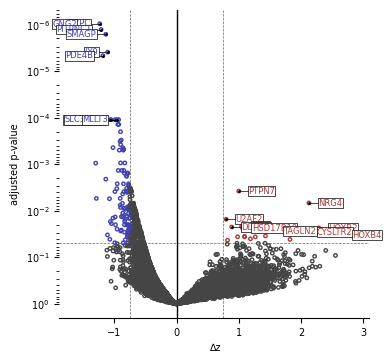

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""U2AF2""",null,-1.620094,2.715419,-0.955246,1.10343,null,1.023559,0.339654,null,-0.714446,null,0.318362,-0.500298,0.557636,-1.304735,0.176765,0.3282,1.025945,-0.551692,0.323235,-0.649471,-0.719877,-0.86863,2.388944,null,-1.54458,null,null,null,null,0.403846,-0.007665,0.287849,0.578713,0.093247,null,…,-1.189254,0.591416,null,-0.957806,-0.503278,null,-0.222967,1.553144,null,null,null,0.523672,-0.382276,0.075079,-1.328085,0.307511,-1.287497,0.059992,null,-1.871968,-1.21208,0.027668,-0.891193,null,null,0.45206,0.997043,0.980193,null,0.263899,0.457718,0.839611,null,0.886613,0.796267,0.000153,0.015288
"""HSD17B10""",null,-0.558325,-0.823437,-0.112002,0.939821,null,-0.816918,0.350841,null,-0.042347,null,-1.089116,-1.051816,-0.590217,-0.727356,-0.863117,0.612388,-0.389434,-1.181731,1.611865,-0.556222,-0.277403,-1.698999,-1.665506,null,0.076187,null,null,null,null,0.365699,-0.101681,0.332709,0.475336,0.367635,null,…,-0.654098,-0.53183,null,-1.156826,-1.096417,null,1.236696,-0.788306,null,null,null,2.622889,0.097768,-1.372473,-0.763792,1.725702,-0.65264,2.344274,null,-0.768205,0.152239,0.263183,-1.606272,null,null,0.079743,0.580533,0.758967,null,1.166973,1.289105,1.367387,null,1.242242,1.058767,0.000318,0.023541
"""SF3B2""",null,1.709797,1.029995,-1.419112,0.695925,null,-0.44282,0.499734,null,0.072929,null,-0.11493,1.281247,0.042007,-1.158614,0.033318,-0.51259,-0.190817,-0.493716,0.677435,1.145404,0.955143,-0.076305,1.099895,null,2.333076,null,null,null,null,0.031124,-0.757676,-0.020985,-0.974546,-1.047748,null,…,-0.644114,0.3247,null,-0.128587,-1.837336,null,-0.885823,0.409256,null,null,null,1.138132,-1.331668,1.05053,-1.489707,-0.506781,0.7645,-1.506493,null,-1.83845,-0.51383,-0.823283,-2.167067,null,null,1.67334,0.549634,0.078342,null,0.869884,0.918718,1.350309,null,1.24849,1.092036,0.000666,0.035851
"""LGALS8""",null,2.156097,-0.490061,-1.298008,-0.611834,null,-1.146823,0.56784,null,0.585578,null,-0.275601,-0.428722,-1.287266,0.896284,-0.906752,-0.217639,0.244222,1.928495,0.576847,-1.269843,-0.042902,0.627017,0.697715,null,-0.903801,null,null,null,null,-1.283179,-0.553687,0.161256,-1.569718,-0.335477,null,…,0.031574,-0.673332,null,0.872956,-1.46598,null,-0.297906,0.630485,null,null,null,-1.501538,-1.416426,0.397972,-0.418811,1.092481,0.041426,0.479401,null,-0.349932,0.423884,-0.513795,-0.321809,null,null,0.805039,0.981398,0.706854,null,1.357723,0.547904,0.060607,null,0.556532,0.818948,0.000941,0.043207
"""HOXB5""",null,-0.465338,-0.138313,-0.316384,-0.476053,null,-0.476053,-0.476053,null,-0.435044,null,-0.472452,-0.471251,-0.476053,-0.476053,-0.476053,-0.476053,-0.476053,-0.472868,-0.473496,-0.476053,-0.43666,-0.476053,-0.476053,null,-0.476053,null,null,null,null,-0.476053,-0.472548,-0.476053,-0.476053,-0.476053,null,…,1.05807,-0.476053,null,-0.47094,-0.476053,null,-0.476053,2.831383,null,null,null,-0.413179,-0.473849,-0.476053,-0.259249,2.639613,-0.406834,-0.396823,null,-0.476053,-0.406359,-0.476053,-0.312082,null,null

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ZNF200""",null,-0.902685,-0.778953,1.145721,3.295952,null,-0.398878,-0.138527,null,-0.126564,null,-0.195449,0.654759,1.002838,0.397078,-0.693692,2.605772,-0.717235,-0.289217,-0.219197,-0.582715,0.916775,-0.621102,3.188792,null,-0.207685,null,null,null,null,-0.991077,0.425478,0.13372,1.122707,-0.791013,null,…,-0.413447,-0.20278,null,2.004863,0.147723,null,-0.54666,-0.991984,null,null,null,-0.25163,-0.797669,1.120633,0.244697,-0.108559,0.17369,-0.453228,null,-0.99632,-0.917011,-0.360503,0.961543,null,null,-0.828185,-0.784653,-0.35738,null,-0.831393,-0.308344,-0.825699,null,-0.703641,-0.757436,0.000068,0.009526
"""ELOVL5""",null,1.059222,-0.549701,1.400762,-1.16654,null,0.229399,0.486601,null,1.192544,null,-0.383586,3.677548,0.654342,-0.063435,-0.655491,3.348824,0.116596,0.845255,0.085229,-0.825615,-0.088911,-0.70216,-0.770528,null,0.783693,null,null,null,null,-1.247714,0.063486,0.363769,0.450655,-0.086127,null,…,0.0062,0.975153,null,-1.815215,0.037457,null,-0.610168,-0.241598,null,null,null,-1.090983,0.282435,-0.859606,-0.100953,-1.002407,-0.066194,-0.58671,null,-0.280567,-0.211006,1.925702,0.013325,null,null,-0.99425,-0.852619,-0.412418,null,-0.066953,-1.025663,-1.1931,null,-0.8827,-0.886156,0.000377,0.026162
"""HGF""",null,-0.776759,0.232989,-0.070532,-0.592506,null,-0.413975,0.357795,null,0.344806,null,-0.349275,-0.816407,-0.647012,-0.699218,0.022919,-0.343147,-0.255849,0.298701,0.016935,-0.233687,0.107269,-0.772169,-0.848121,null,-0.212199,null,null,null,null,4.319336,0.800823,-0.50117,0.565893,0.196897,null,…,-0.756827,1.605266,null,-0.732634,-0.839624,null,-0.341331,-0.763584,null,null,null,-0.091021,2.525269,-0.487976,1.838385,0.507891,-0.845785,0.295345,null,-0.441914,-0.85114,0.52923,2.657745,null,null,-0.60869,-0.826757,-0.748143,null,-0.711284,-0.735799,-0.543685,null,-0.520371,-0.766486,0.000008,0.002889
"""ARAP2""",null,-0.519503,-0.147476,-0.113186,1.240846,null,-0.335407,-0.37623,null,-0.269012,null,1.165435,1.118461,2.263291,2.648593,0.713454,1.412077,-0.323905,0.119884,-0.549893,0.460425,0.354685,1.536954,-0.905572,null,-0.106137,null,null,null,null,1.687918,-0.555654,1.91852,0.144141,0.185149,null,…,-1.401939,-0.867513,null,1.16802,-0.76437,null,-1.398296,0.498267,null,null,null,-0.950278,-0.038388,1.680595,-0.769532,-0.419341,-0.019556,-0.238057,null,-1.066527,-0.723451,1.576885,-0.809863,null,null,-1.251378,-0.994034,-0.371134,null,-0.681704,-1.109803,-0.404295,null,-1.437777,-1.020429,0.000135,0.014463
"""GALC""",null,0.449334,-0.708827,-0.157989,-0.791456,null,-1.113725,-1.187672,null,-0.02609,null,0.232438,0.10722,0.291563,-0.137761,-0.882842,0.304846,-0.224501,-0.655283,0.200695,-0.178819,0.931645,-0.696317,-1.31751,null,0.860631,null,null,null,null,-0.60171,3.213999,-0.720524,-0.40397,-0.121761,null,…,0.00342,4.388299,null,0.548809,-0.58309,null,-0.559071,-0.766221,null,null,null,-0.49552,2.084689,0.259665,0.194699,0.29735,-0.454873,1.555844,null,0.23008,0.187837,-0.143842,1.518435,null,nul

Proteomics


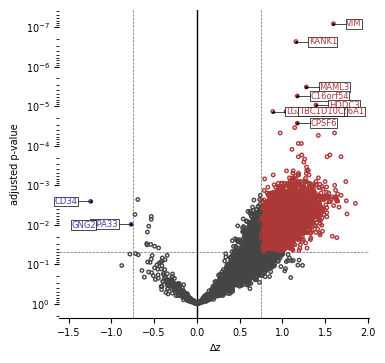

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS""",-1.542259,-1.395823,-0.447862,-0.980851,null,null,null,null,null,null,-1.947741,-1.136345,-1.120729,-0.939463,-1.616692,-1.874056,-0.217609,-0.456842,-1.511112,-0.832212,-0.748149,-0.401336,0.450722,-0.796796,-0.682444,0.138926,-0.347163,0.467166,-0.936152,0.857692,2.113329,0.791053,-0.308266,1.023863,0.542062,0.3426,…,-0.031399,1.46986,1.405213,0.285131,-0.128239,0.343336,-0.42078,-1.988544,-0.236326,-1.397439,-0.034244,1.58668,0.135788,-0.206442,1.022811,1.102638,-0.013074,0.928004,0.054984,0.159476,0.366877,0.970719,-1.267366,2.645251,-0.18844,-0.013034,null,0.70166,1.336155,0.708376,1.706465,1.578477,0.316274,-0.136293,0.870115,0.009994,0.017451
"""AACS""",0.016082,0.891129,0.014929,0.230692,null,null,null,null,null,null,-2.154921,-2.036157,0.586052,0.044943,-1.254978,-1.919572,-0.983412,-0.481312,-1.884537,-0.58567,-1.136294,0.515246,-0.747527,0.509453,0.612145,0.656307,-0.171533,-0.217533,-0.81261,0.097776,-0.319522,-0.960065,-1.13896,-2.883177,0.162554,-0.091256,…,0.368588,-1.067844,1.252179,-0.501623,-0.753393,-0.789782,-0.314534,-0.266404,1.436187,1.556085,0.029323,0.206673,1.82686,-0.603951,-0.186946,1.051341,0.529674,0.916148,1.730691,-0.131115,0.849734,-0.400351,-0.354508,1.41537,-2.019163,1.083997,null,0.887867,-0.319743,1.710934,2.057709,1.274579,0.507716,0.761482,1.118099,0.002742,0.007738
"""AAGAB""",-0.618605,1.092347,0.103645,0.071595,null,null,null,null,null,null,-2.510515,-2.470933,-0.670336,-0.968585,-0.292929,-0.822523,-1.921802,-1.082432,-1.353139,-0.438344,-0.97086,-0.404948,0.233059,0.080315,-0.240851,0.042966,-0.103969,-0.46013,-0.664431,0.246239,-0.266921,0.975007,-0.644519,-1.278079,0.085209,0.16072,…,0.040528,-0.830976,0.87779,-0.380387,-1.154639,-1.146293,-0.645516,-0.191312,1.884401,0.652709,0.748392,-0.131609,1.855103,-0.217422,-1.114269,1.671624,-0.052839,-0.266978,2.161232,-0.276165,0.936151,-0.834007,0.013851,1.742052,-1.213686,0.33313,null,1.381746,0.373073,1.750704,2.40928,0.452147,0.892648,0.916453,1.194558,0.001875,0.006304
"""AAK1""",-0.207097,1.02427,0.009679,-0.033026,null,null,null,null,null,null,-1.689299,-2.03898,-2.07001,-0.8117,-0.413482,-2.366944,-1.3957,-1.303839,-1.260513,-0.104213,-0.959681,-0.405905,-0.786658,1.283918,0.075197,-1.203633,0.144542,-0.16955,-0.742618,0.58737,-0.363489,-0.120275,-0.885915,-0.648691,-0.160846,0.122917,…,0.481692,-1.030489,-0.087672,0.111969,-0.151138,-0.596446,-0.380569,-1.146551,1.230414,0.089163,0.396183,1.171746,1.470221,0.621141,-0.204764,2.463535,0.590068,0.554144,2.023098,0.569228,0.775063,1.620893,-1.274666,-0.375303,-1.276747,0.101477,null,0.850621,0.237815,1.66316,1.993524,0.70526,1.411545,0.694378,1.075034,0.001991,0.00649
"""AAMDC""",-0.206425,-0.716536,0.783744,-0.058159,null,null,null,null,null,null,-1.037646,-1.939039,-1.345919,-0.033993,-1.129138,-1.613604,-1.352352,-0.391569,-1.6348,0.33674,-1.712471,-0.055434,-0.386299,0.672554,0.572812,0.658969,-1.539663,-0.659174,-0.148407,-0.30471,0.390307,0.0286,-0.746569

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD34""",-1.33872,-0.980798,1.080388,-0.131088,null,null,null,null,null,null,-0.660135,0.297102,-0.850579,0.941584,-1.443437,-1.528937,0.518846,-0.072907,-0.629734,-0.02597,-0.018339,-0.166496,1.03868,-2.054367,-0.424055,0.094191,0.973697,0.987715,-0.44802,1.132376,1.150005,0.767481,1.480259,-0.149164,1.650466,0.193302,…,-0.913241,0.151168,-0.447166,0.862103,1.416539,1.066651,0.618699,0.106913,-1.849179,1.148626,-0.642678,0.794784,-0.990593,-0.608879,1.740851,-0.905314,-1.568392,0.253007,-0.313234,-0.459378,-0.165622,0.65807,-1.681517,1.681857,0.484016,-0.958597,null,-0.065967,-0.864971,-1.499578,-1.121057,-0.881617,-1.388331,-2.070577,-1.242501,0.000196,0.00258
"""GNG2""",0.987054,0.731423,0.962429,0.230861,null,null,null,null,null,null,-1.26674,-0.837316,-1.340219,-0.911182,-0.157821,-2.104162,0.495725,0.649158,-1.493337,-0.497443,-1.598348,0.591744,-0.769626,-1.477014,0.893331,-1.204894,0.776134,1.547091,-1.217185,0.759204,0.437073,0.033086,-0.554446,-1.212915,2.003723,1.577556,…,0.841976,0.757222,0.96487,-0.225208,-0.222017,-0.678326,-0.352984,-0.430455,0.232757,-0.711076,-0.808853,1.559267,0.981739,-0.840346,0.792722,0.453524,0.210594,0.03007,0.886084,1.180263,0.35999,1.496161,-1.291466,-1.043752,0.828842,-0.339391,null,-0.071136,-1.567922,-0.636551,-1.27725,-2.276018,-0.542974,-0.628692,-1.030414,0.004545,0.010385
"""GPA33""",0.281515,-0.556526,0.783872,-0.108813,null,null,null,null,null,null,-1.263055,-1.002622,1.286596,0.390773,0.240369,-1.34405,0.355541,-0.008036,-0.901885,0.68619,0.430101,-0.143771,-0.802969,0.150439,0.964203,0.065272,0.985084,1.020368,-1.472047,1.271817,0.156676,1.08182,-0.650867,-0.577541,0.780508,0.728762,…,0.644107,2.340322,-1.108188,1.469293,0.805168,1.494614,0.170557,-2.003808,-0.485881,-1.817537,-0.788839,1.039603,0.345817,0.345893,0.668575,-0.25265,-0.865987,0.154762,-0.947338,-0.612628,-1.11764,1.818458,-2.147858,-0.254639,0.912806,-0.201842,null,-0.925906,0.170046,-1.198953,-0.197268,-0.942481,-0.940218,-1.236946,-0.768405,0.004106,0.009817


Phosphoproteomics


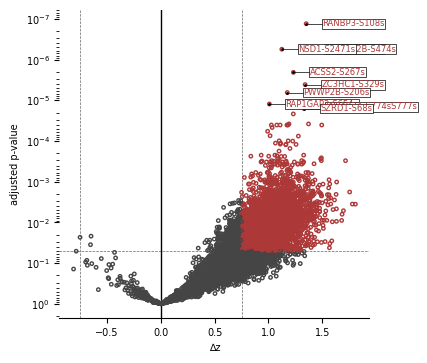

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S20s""",-0.232702,0.797706,-0.735363,null,null,null,null,null,null,null,-1.530117,null,-2.493254,-0.6046,-0.76177,-1.265441,-1.106084,null,-0.510382,-0.590834,-1.100266,-1.147387,-0.583367,null,-0.292071,-0.106818,-1.024001,null,-0.417458,null,-0.313824,0.018426,null,null,null,null,…,0.053347,null,0.235535,null,-0.651687,0.01545,null,-0.730482,1.019936,-0.220521,null,1.661606,null,1.047111,-0.54162,null,0.404963,1.057119,2.168077,0.231329,null,2.085892,-0.893581,null,-1.332266,0.479436,null,0.354492,null,1.92029,1.802266,0.59829,1.556108,1.191039,1.308435,0.000891,0.006309
"""AAK1-S670sT674tS678s""",null,null,0.455455,null,null,null,null,null,null,null,-1.329943,-0.843083,null,0.45729,-0.454744,-1.302413,-1.110538,-0.810255,-0.249454,-0.338462,-0.847554,0.090271,-0.573825,0.550462,-2.846388,-0.93214,0.023267,-0.734712,-0.796241,0.452822,0.01258,0.052558,-0.850748,0.82642,0.761471,0.012194,…,1.518777,-0.788581,-0.460917,-0.195487,-1.237785,-0.243975,-0.648986,-1.214978,0.999944,-0.095225,0.374329,1.433229,1.511664,1.262773,-0.237777,2.402747,0.875055,0.016575,1.413604,0.866005,-0.55373,1.60941,-1.704015,-2.134276,-0.983334,null,null,0.789232,0.80306,1.606202,1.584997,0.50505,0.892894,0.858839,1.121168,0.000056,0.001679
"""AAK1-T606t""",-0.322396,0.10375,0.797769,0.103229,null,null,null,null,null,null,-1.806668,-1.441886,-2.269473,-0.775226,-0.606671,-1.972968,-1.451819,-0.869878,-0.559534,0.112661,-0.834578,-0.410351,-0.803694,1.262689,-0.663979,-1.717362,0.311043,-1.273521,-1.136501,0.306615,-0.183597,-0.34626,-1.348001,0.265863,0.722519,0.430393,…,0.259503,-0.860097,0.07884,-0.073961,-0.500951,-0.410384,0.003157,-0.442278,0.693932,-0.456918,0.879153,1.262155,1.7895,1.254882,-0.215905,2.262415,1.042247,0.375981,2.247974,0.817115,0.935572,1.692447,-1.248356,-0.904164,-0.90432,0.234047,null,0.315854,0.345743,1.355507,1.921856,0.894243,1.619147,0.325176,0.984317,0.003636,0.013175
"""AAK1-T620tS624s""",-2.395924,0.42425,0.647879,0.218306,null,null,null,null,null,null,-1.574906,-1.36241,-2.258463,-0.413229,-0.487655,-2.322964,0.492773,-0.709911,-0.134459,-0.262526,-1.048038,0.012668,-0.633445,0.669615,-0.978641,-1.045371,0.033262,-0.849793,-1.082221,0.19884,-0.131475,0.111885,-1.425769,0.031455,0.5668,0.504861,…,0.546097,-0.582118,0.329194,-0.147537,-0.647646,-0.049956,-0.204543,-0.801346,1.083412,-0.355012,1.146894,1.65399,1.467295,0.779671,0.190812,1.973767,0.621884,0.378532,2.257744,0.573753,0.849716,1.402597,-1.394672,-1.117278,-1.023326,-0.188633,null,0.875268,0.578818,1.624735,2.064824,0.751864,1.263896,0.400437,1.034804,0.003799,0.013492
"""AAK1-T674tS678s""",-0.458286,-0.195471,0.610625,-0.117859,null,null,null,null,null,null,-1.530335,-0.658471,null,0.234339,-0.132423,-2.121357,-1.368472,-0.890955,0.161861,-0.187648,-0.749091,-0.08093,-0.687459,0.84429,-1.800279,-1.154295,-0.043728,-1.187935,-0.627721,1.325322,0.025383,-0.102012,-0.901031,1.102721,0.449038,0.245429,…,0.596065,-1.246509,-0.963103,0.012848

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Acetylomics


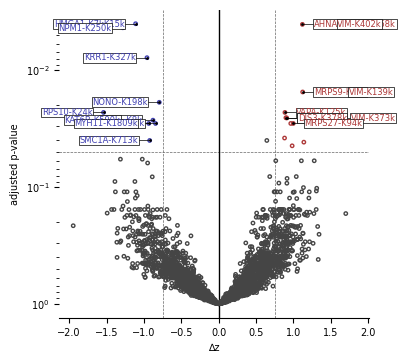

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AHNAK-K1191k""",null,null,-0.409537,null,null,null,null,null,null,null,-0.592183,-0.639776,null,-1.295853,-0.31846,-1.387377,null,0.555547,-0.680948,-1.690519,0.163981,0.15759,0.617604,-0.809699,-1.926661,-1.066366,0.127992,-0.76505,-0.507607,1.055319,-0.24687,-1.383066,-1.028338,-0.975132,0.300195,-0.155278,…,1.215696,-0.668325,1.606989,1.03937,-0.884531,-1.565864,0.139531,0.302018,1.460872,-0.003613,-0.289214,1.931619,1.619072,0.208486,-0.130458,1.139304,1.092819,0.110837,1.615991,0.411436,0.826509,0.090287,null,-1.708284,null,null,null,1.327493,0.166164,1.414802,1.353841,0.447004,1.43492,0.976478,1.140014,0.000363,0.041341
"""AHNAK-K807k""",null,null,-1.751149,null,null,null,null,null,null,null,null,null,null,0.008424,-0.412703,-0.837621,null,0.073031,null,-0.716726,-0.811798,null,-0.430997,-0.804611,-1.542543,null,null,-0.50653,null,null,-1.245212,null,null,-1.219413,0.102464,null,…,1.150678,-0.880686,1.169924,null,-1.284869,-0.682797,0.061237,null,1.524512,null,0.84338,0.986118,null,-0.307228,null,null,1.675753,-0.337583,1.779743,null,null,0.885455,-0.485065,-0.463861,null,null,null,1.250547,null,0.940287,0.809248,0.95447,1.251557,0.533258,1.120543,0.000005,0.004055
"""DIS3-K378k""",null,null,-0.252103,null,null,null,null,null,null,null,null,-0.39674,-1.217267,0.213283,-0.591251,null,-0.451776,-0.669314,-0.456634,null,-2.288552,0.763654,0.557979,0.353522,1.71613,-0.402539,0.626968,1.417321,0.767665,-0.019072,-0.677447,1.244084,0.938324,1.959974,-1.260586,-0.598932,…,0.407792,-1.066618,-1.170478,0.021391,-0.441276,0.86261,-0.971819,-0.62739,-0.03104,-0.506983,-0.84763,0.63125,0.163046,0.420606,1.093645,-1.672619,-1.078704,-1.941497,-0.965607,-2.50318,-1.695483,-0.167874,1.205946,1.464193,null,null,null,0.195246,1.254222,1.074303,0.780993,1.10309,0.516496,0.762163,0.910402,0.000131,0.025662
"""ME2-K24k""",null,null,-0.603016,null,null,null,null,null,null,null,-1.112815,-1.239246,-0.965778,-1.290428,-0.446443,-1.052114,-0.049206,-1.43343,0.716645,-2.567152,-0.667961,-1.861779,-0.118292,-0.034372,-0.029235,-0.659998,-1.935584,-0.405139,-0.156679,-1.592586,-0.528088,-1.476407,-0.819898,-1.492794,0.500465,1.321641,…,0.173049,0.514382,0.539606,0.101834,1.480914,1.772503,-0.565761,1.539668,0.402636,-0.069261,0.399707,0.126889,0.160094,0.244499,0.770262,0.230134,-0.333058,0.558715,-0.17598,1.080888,0.141078,-0.17943,0.521009,3.086055,null,null,null,0.732818,1.233095,0.16469,0.742536,1.199615,0.91949,0.659288,0.90001,0.000121,0.02554
"""ME2-K26k""",null,null,0.372618,null,null,null,null,null,null,null,-1.20233,-0.905259,null,-2.420083,null,null,null,null,null,null,-1.079462,null,null,-0.500687,null,-0.180545,-2.342079,-0.875949,-0.021533,-1.514795,-0.504638,null,-0.416189,-1.634806,0.743719,-0.41001,…,0.404642,-0.115382,0.400515,0.14699,null,1.453617,null,1.262918,null,null,-0.013603,0.248809,0.165352,null,0.626123,0.153623,null,null,-0.09335,0.764269,0.472662,null,null,2.673052,null,null,null,0.663399,1.40319,null,0.

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""DDX24-K17k""",null,null,0.77021,null,null,null,null,null,null,null,-2.450976,0.520478,null,1.629619,0.760747,-1.46832,0.861642,0.482243,-0.290174,0.602474,-0.418032,0.711198,0.472996,-0.570067,-2.892446,0.933252,0.548343,0.434202,0.139463,0.66075,1.27977,0.615195,-1.158378,-0.198532,0.311309,-1.081157,…,0.71121,-0.225125,-0.692724,0.30887,-1.416947,0.661372,0.133324,-0.284859,0.249097,-0.411515,1.37822,1.330466,0.522169,-0.543222,0.702424,1.938669,0.970104,0.615218,-0.608296,0.395385,-0.030359,1.082979,-1.283323,-2.893525,null,null,null,-0.799062,-0.83482,-0.12006,-0.74708,-1.200297,-0.537635,-1.055674,-0.844619,0.000189,0.028594
"""HBA1-K8k""",null,null,null,null,null,null,null,null,null,null,-1.814002,null,2.886724,-1.292734,1.868762,1.475922,0.075426,0.103913,-0.097591,-0.836226,0.199435,-0.036456,-0.518895,-0.009647,0.709474,-0.306439,-0.945906,-0.366203,0.817099,-0.50606,-0.946729,0.090547,null,-1.920651,0.665353,1.772924,…,-1.800493,1.350121,0.129875,1.238162,1.573433,-0.406657,0.144227,1.359288,-0.222775,-0.496995,-0.772711,-0.874175,1.418848,-0.227481,0.923564,-0.970347,-0.733178,0.20554,0.113204,-0.520862,1.099527,-1.253071,1.608131,1.655478,null,null,null,-0.459544,-0.80228,-1.08349,-0.398955,-1.382338,-0.849198,-0.512948,-0.878741,0.000153,0.026805
"""HMGA1-K7kK15k""",null,null,1.5962,null,null,null,null,null,null,null,null,1.316096,0.883872,2.277209,1.980379,null,null,0.448202,0.304834,null,1.14101,0.55503,0.800846,-0.907407,null,-0.2621,0.606128,null,null,-1.627948,1.286477,-1.309732,1.12158,0.644168,1.040193,-0.13676,…,-0.217805,-0.935935,-1.512073,0.297202,-0.452735,-0.708694,null,1.158409,null,null,-0.96997,-0.957124,-1.488435,-0.037774,1.900711,-0.174101,null,-0.999933,null,null,null,-1.2386,null,0.633547,null,null,null,-0.78069,-0.855689,-0.634483,-1.249231,-1.296656,-1.049551,null,-1.111042,0.000001,0.004004
"""KAT6B-K590k""",null,null,1.797581,null,null,null,null,null,null,null,0.10849,-0.172791,2.512389,0.752463,0.80284,null,0.858634,0.282918,1.353431,0.47483,null,-0.26577,-0.124558,0.342139,-0.338841,-0.095739,-0.358714,-0.485581,-0.57431,-0.153466,1.575714,0.257285,0.6961,-0.396909,0.410635,-0.629588,…,-0.022472,1.75316,-0.462296,0.756272,2.638711,0.675844,null,-0.172342,-1.357621,-0.391512,-0.735438,-0.055902,0.148787,-0.310385,-0.105775,0.897561,-0.487497,-0.726755,-0.970885,-1.583261,-0.341104,0.540282,-0.859953,2.391114,null,null,null,-1.659487,-1.095019,-1.008629,-0.640826,-1.089802,-0.254695,-1.517218,-1.165422,0.000157,0.026805
"""KRR1-K327k""",null,null,0.434016,null,null,null,null,null,null,null,0.154724,-0.057279,null,-0.622741,null,null,null,-1.07847,null,null,-2.45707,null,null,1.191919,null,1.427938,-0.663264,-1.611693,0.624131,-0.117739,0.636215,null,0.850775,2.191232,0.285645,-1.834811,…,0.174886,1.044403,0.792175,1.194143,null,1.289076,0.026143,0.920725,null,null,0.053391,0.317515,0.262226,null,1.400113,-0.439517,null,null,-1.350426,0.591679,-1.304844,null,null,0.285653,null

Lipidomics


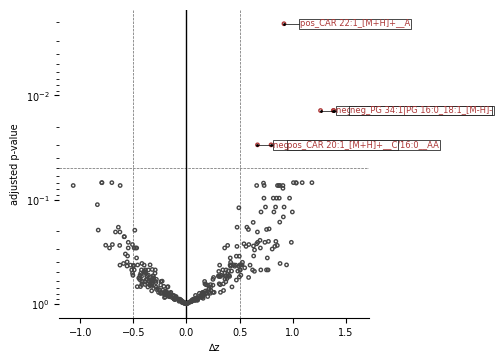

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.304298,null,0.205666,null,-1.877715,-2.336927,-0.671176,-0.559277,-0.89684,0.730015,-1.528752,0.924474,-0.121785,2.107107,0.158423,-1.873054,-0.017167,0.410613,-0.225106,0.735596,-1.569228,-0.574981,-0.465229,-0.156281,-1.043631,-0.057784,-0.333594,0.473044,-0.109398,0.364759,0.730195,0.993495,-1.085776,0.540492,0.794747,-1.860314,…,-0.021828,0.976691,0.444138,0.547362,-0.154064,1.175937,0.78952,-1.591981,-0.033355,-0.954576,-0.48851,0.489138,-1.474352,0.631859,0.883681,0.418319,0.686194,0.095807,-0.267403,-0.912236,-0.795319,0.313918,-0.62282,0.909535,null,null,1.017552,1.520874,1.923878,0.151462,1.420306,1.782571,1.387895,0.680967,1.381063,0.000093,0.013984
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.215346,null,0.795471,null,-2.441927,-1.966074,-0.915823,-0.483266,-0.888357,0.279216,-0.10746,0.794978,-0.830775,1.136461,-0.391025,-1.149383,-0.903751,-0.814991,-0.488269,-0.294001,-1.121868,-1.291125,0.036713,-0.093762,1.331255,0.399075,-0.539235,-0.968015,-0.854319,-0.551013,0.797477,0.237136,-0.41343,-0.34982,0.006833,0.022341,…,0.769201,0.748982,-0.021423,1.039508,0.074314,0.546116,-0.632635,-1.389862,-0.30681,1.144033,-1.361237,0.865305,-1.094948,2.380518,0.463456,0.148231,0.258864,0.203508,-1.024416,-0.035257,-1.473879,0.433882,-0.004088,2.162146,null,null,0.321056,0.892991,0.797209,2.014038,1.861902,1.040461,0.748887,1.351352,1.26125,0.000163,0.013984
"""neg_PG 34:1|PG 16:0_18:1_[M-H]…",-0.205396,null,0.031842,null,-1.831716,-3.062592,-0.928186,0.60297,-0.849304,0.8729,-1.121139,-0.416984,-0.813994,0.042516,0.396488,-0.287271,1.795314,-0.098581,0.628072,0.191241,-0.114138,-0.797626,0.257833,1.109374,-1.333077,0.040091,-0.401328,-0.289162,-0.362862,-0.315529,0.470478,0.791083,0.004885,-0.133265,-0.345279,-2.067787,…,0.700857,-0.370926,-0.150908,0.701229,-0.714112,1.366321,0.647525,-2.265112,0.111549,-1.589143,0.004477,0.397401,-0.960381,-0.249218,0.619373,0.242803,2.020892,-0.307827,-0.050037,-0.298481,-0.49068,0.572829,-0.833025,1.572983,null,null,1.447593,1.402217,1.735445,0.133069,1.566282,1.538911,1.718625,0.37664,1.385712,0.000152,0.013984
"""neg_Cer 34:0;O2|Cer 18:0;O2/16…",-1.929054,null,0.301641,null,-1.819633,-0.501177,-0.285401,-1.434868,-0.599438,-1.213825,-2.271972,-0.763527,0.768989,-0.988629,-0.511189,-0.631727,-1.244881,-0.643251,-1.593708,0.377354,-1.456893,0.349845,-0.785837,-0.273164,1.555054,0.552548,-0.616584,-0.58618,0.211064,-0.098901,0.49877,0.551995,-0.960873,-1.016063,-0.477969,-1.101275,…,3.112607,1.51504,0.23507,0.039361,-0.272892,-1.236075,-0.181238,0.055396,0.542992,0.892248,-0.587752,0.867874,2.006358,0.904088,0.49064,0.573361,0.902955,0.288372,0.006994,0.794276,1.084828,0.654425,1.548285,2.028271,null,null,0.620788,0.307886,0.72327,1.267434,0.579575,0.696598,0.221764,0.364372,0.66803,0.000522,0.029847
"""pos_CAR 20:1_[M+H]+__C""",1.239538,null,-2.591464,null,0.047537,0.535362,-0.419661,-0.173415,-0.157501,0.234604,-0.870406,-0.091353,-0.163673,-0.

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Metabolomics


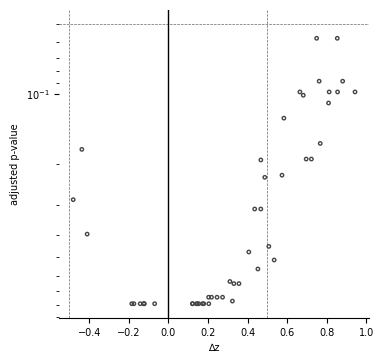

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITDxNPM1-WT ============
Transcriptomics


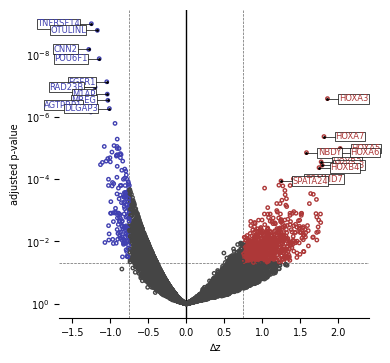

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SARM1""",null,-0.877701,null,-0.65171,-0.85041,null,-1.023292,-0.799344,1.636794,-1.022921,-1.039287,-0.972078,-0.662364,-0.903129,-0.862983,0.022863,-1.016854,-1.177662,null,0.614546,-0.790077,null,null,-0.351337,-1.139606,-0.76965,-0.24241,null,-0.991596,0.44202,-0.219142,-0.693387,0.357854,-0.887782,-0.181789,null,…,null,null,null,null,null,null,null,null,null,null,0.177006,1.829341,-0.777487,0.317893,-0.378989,null,null,1.584777,0.878849,1.318459,null,1.402476,0.024148,null,0.490286,null,1.45356,0.584368,0.449715,0.502989,null,1.866341,1.180483,null,0.9639,0.000145,0.00511
"""DVL2""",null,0.97082,null,1.138095,-0.916933,null,0.382584,-0.725174,-0.184571,-0.419465,0.350802,-0.52162,-1.176702,-1.056591,0.778772,0.771227,-1.636757,-1.388091,null,-1.392316,-1.481718,null,null,1.44878,0.803229,-0.608768,-0.609173,null,-1.106106,-0.028363,0.056034,-0.454076,-0.253449,0.098832,0.425875,null,…,null,null,null,null,null,null,null,null,null,null,0.984728,2.398989,1.63255,0.035565,-0.627869,null,null,0.522642,0.860971,1.056407,null,1.600164,-0.667064,null,1.478116,null,1.310516,-1.010849,0.774023,0.005546,null,1.682686,0.618544,null,0.945335,0.001127,0.016135
"""LIG3""",null,-0.151467,null,-0.33892,-0.489638,null,0.522734,-0.369341,-0.202582,-1.453795,-1.695998,-0.36646,-1.732867,-1.353166,-0.720057,-0.478218,-0.973628,-1.475048,null,1.113025,-1.823392,null,null,0.944806,-0.370645,0.732547,0.663157,null,-0.420892,1.729488,-0.551118,-0.543925,0.210022,-0.094932,0.860226,null,…,null,null,null,null,null,null,null,null,null,null,1.009836,2.024756,-0.073366,0.625371,-0.078605,null,null,0.509287,0.391246,1.221684,null,0.432412,-0.81632,null,1.352943,null,3.743926,0.041523,0.329605,0.751859,null,2.572171,0.706887,null,1.101417,0.000895,0.014059
"""WDR54""",null,-0.509161,null,-0.310385,-1.388758,null,-0.177727,-0.379717,0.822861,-0.966683,0.025753,-0.146608,1.325045,-0.449613,-0.265709,-0.349708,-1.606747,-0.32512,null,-0.116603,-1.588371,null,null,-1.327487,-0.570411,-0.534638,-0.504323,null,0.30384,0.035633,0.887749,-0.889401,-0.93997,-0.360302,1.382969,null,…,null,null,null,null,null,null,null,null,null,null,0.109022,-0.890412,-0.541938,1.563398,0.526266,null,null,2.887537,0.810537,2.557424,null,0.814262,-0.480732,null,1.171199,null,1.639306,-0.00282,1.615946,1.022527,null,1.293784,0.15775,null,1.064654,0.000891,0.014049
"""GDE1""",null,0.758226,null,0.260086,-1.268099,null,1.263094,-0.272044,0.017704,0.541863,-1.747178,-0.986999,-0.023057,-0.798709,2.638004,-0.051162,-0.869443,-0.453551,null,-1.910616,-0.82267,null,null,1.152661,-0.793509,-0.51519,-0.701861,null,0.552197,-0.687321,-0.122369,0.567641,-0.066183,-0.528979,-1.050659,null,…,null,null,null,null,null,null,null,null,null,null,1.396058,1.611347,2.788271,0.870785,-0.810908,null,null,1.000963,0.791108,0.325348,null,0.709463,1.292448,null,0.638681,null,0.008604,-0.423066,0.635391,0.37941,null,0.668425,1.114906,null,0.970848,0.000225,0.006553
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ST7""",null,0.647423,null,2.509013,0.549558,null,-0.687299,-0.300414,-0.216114,-0.123449,1.20141,-0.941357,-1.016609,-0.6177,0.586022,0.415973,-0.60585,-0.811152,null,0.753136,-0.666466,null,null,1.034291,2.541823,0.605907,1.109047,null,-0.303913,1.676371,-0.112385,0.496539,0.654265,0.379471,-0.899235,null,…,null,null,null,null,null,null,null,null,null,null,-1.37069,-1.363661,-1.363733,-1.321576,-0.009784,null,null,-0.778901,-1.337348,-1.00753,null,-1.364083,-0.14939,null,-1.380552,null,-1.216278,-0.425584,-1.360068,-0.399639,null,-0.72057,-1.269721,null,-1.257823,5.8887e-10,7.0527e-7
"""KDM7A""",null,-0.366398,null,-0.726779,1.052546,null,-0.580649,0.481196,0.693235,1.142471,-1.060895,0.870381,-1.140374,-0.00304,-0.252134,0.180498,2.662563,0.606359,null,1.148474,2.302163,null,null,-0.318794,-0.904026,-0.746796,-0.311068,null,0.157268,-0.547705,-0.621326,-0.278208,1.191963,0.053336,-1.00754,null,…,null,null,null,null,null,null,null,null,null,null,-0.961088,-1.238572,-0.000579,-0.664734,-0.867177,null,null,-0.59072,-0.661974,-0.151132,null,-1.443099,0.137198,null,-0.915028,null,-0.695443,-0.218841,-0.753128,-0.896816,null,-0.243197,-0.259806,null,-0.778647,0.000021,0.001558
"""ELOVL5""",null,0.973571,null,1.706359,1.073595,null,0.363955,0.619425,1.699127,-0.148634,0.270305,-1.196692,-1.477024,-0.254172,-0.093943,0.79516,2.061339,-0.284704,null,2.099682,0.518171,null,null,2.836847,0.343133,0.759826,0.49527,null,-0.331627,-0.321524,-0.45419,0.212799,1.157903,-0.075967,-0.83564,null,…,null,null,null,null,null,null,null,null,null,null,-0.898079,-0.625711,0.237027,-0.803125,-0.454659,null,null,-1.090791,-1.716811,-0.2759,null,-1.55175,-1.194278,null,-2.656985,null,-0.026292,0.71679,-1.218546,-1.76836,null,0.832613,-1.178773,null,-1.021373,0.000398,0.009053
"""VAMP3""",null,1.723438,null,-0.430541,1.149889,null,-0.351758,1.435521,0.401263,2.306573,-0.269883,1.592967,0.333261,1.347897,1.278531,-0.575716,0.739966,-0.361481,null,0.036386,3.184092,null,null,-0.30796,0.017456,-0.214333,-0.244593,null,1.867143,-0.790548,-0.582291,-0.637798,0.08369,-0.182749,-0.650349,null,…,null,null,null,null,null,null,null,null,null,null,-0.59718,-1.504459,-2.055268,-0.372003,-0.789094,null,null,-1.320974,-0.399647,-0.896968,null,-0.272945,0.511147,null,-1.056391,null,-0.890117,-0.087089,-0.468544,-0.471064,null,-0.159738,-0.541376,null,-0.849427,0.000072,0.003359
"""NEDD4L""",null,2.457832,null,-0.751447,2.467761,null,-0.355211,-0.690596,0.224386,-0.884094,-0.338185,-0.615318,-0.689571,-0.495185,-0.205074,1.398168,0.104968,0.707849,null,0.92066,0.109943,null,null,-0.885007,-0.156141,3.216763,2.427635,null,-0.79122,-0.876334,-0.606353,1.709675,0.925339,-0.766745,-0.873531,null,…,null,null,null,null,null,null,null,null,null,null,-0.940121,-0.951287,-0.821633,-0.77306,-0.664477,null,null,-0.404115,-0.82274,0.046886,null,-0.910999,-0.441127,null,-0.950441,null,-0.482323,-0.770298,-0.409392,-0.63848,null,-0.366278,-0.803806,null,-0.829407,3.6070e-7,0.000102
…,…,…,…,…,…,…,…,

Proteomics


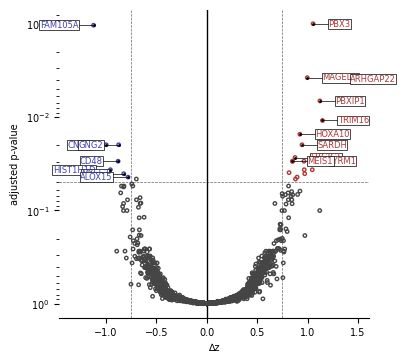

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ARHGAP22""",null,0.285923,-0.18177,-0.989095,-0.21305,-0.585831,-1.779033,-1.672788,0.565205,-0.368538,1.407788,-0.038947,-0.183689,-0.417637,0.202544,null,-1.130992,-0.439154,0.166135,null,-0.55439,1.299964,null,-1.008907,-0.6324,-0.12958,null,0.241102,null,null,null,null,-0.992888,-0.49211,-0.020243,-0.808925,…,-0.293116,-1.212125,-1.387367,-0.043843,1.696012,2.270245,null,-2.114708,0.319425,0.595292,1.679291,2.549735,1.646576,null,0.748884,1.502666,null,0.419387,0.488808,null,-0.056595,1.120712,null,null,1.530612,1.532463,1.67701,0.39725,0.74258,1.131054,null,0.478591,0.405144,0.665008,1.271627,0.000002,0.003926
"""ERGIC1""",0.03758,0.056278,0.163642,0.287351,-1.618583,-0.671211,-1.99084,-1.813229,-1.553428,1.044452,0.681933,-0.001001,0.568407,-0.730492,-0.510454,-1.392062,-1.777052,0.167684,0.136746,-0.251473,-1.136575,0.613606,1.400412,0.644478,0.917393,-0.224841,0.488176,1.618736,0.104554,0.230101,-1.173456,0.366662,-2.32224,-0.17467,0.488659,-0.154658,…,-0.920075,-1.388942,-0.762093,-0.894345,1.616262,1.488113,-0.337216,-1.342358,-0.264229,0.97276,1.937866,2.328599,1.456469,-0.672701,0.061159,1.006158,0.834811,-0.494338,1.146395,0.012312,0.413056,1.433174,0.974515,0.338532,1.113456,1.554479,1.809156,0.892353,0.73635,0.882488,-0.507805,-0.054097,0.442505,-0.549941,0.875434,0.000037,0.02706
"""HOXA10""",-0.36857,0.066237,0.622445,-1.246479,-0.937408,-0.760719,-1.503591,-2.298043,-0.787549,0.243476,-0.06642,-0.444389,1.965764,-0.701001,1.085962,-0.040245,-0.949857,-0.551535,1.100717,-0.122495,-0.928976,-0.210803,-0.961235,-1.079592,-0.371165,0.311913,1.254641,-0.355129,0.340185,0.332647,-0.923169,-0.278501,-1.268928,-0.586278,0.946271,-1.100855,…,1.708627,-0.834786,-0.847285,-0.752433,1.481576,1.357988,1.104167,-1.424353,-0.216718,1.00307,1.533126,1.25854,1.687037,0.986539,1.543697,0.099168,0.549562,1.686843,0.502049,0.522651,-0.285003,0.828166,1.032009,0.566867,-0.293875,1.647023,1.617551,0.822916,0.441309,1.216965,-1.907108,0.442681,-0.364975,0.843139,0.923436,0.000013,0.015229
"""HOXB4""",-0.107139,0.603575,0.613642,-1.360147,-1.021439,0.254293,-2.002311,-1.901911,-0.660291,-0.394449,0.353873,-0.933478,1.082121,-0.42256,-0.513255,1.002023,-0.788862,0.3338,-1.39865,-1.005848,-0.729409,-0.406842,-0.51773,-0.357281,1.285464,-0.587673,0.360686,0.449308,-0.14153,2.466914,-0.716665,-0.275086,-1.14421,0.245779,0.654416,-0.606104,…,null,null,1.014585,0.51359,1.996714,1.208129,1.190237,-1.483242,0.462803,1.399519,1.844311,2.123695,1.253613,0.414551,1.44221,0.457774,0.747355,0.57445,0.400104,-0.312289,-0.003238,1.029426,1.476389,-1.377049,0.38953,0.875546,1.172571,1.75998,-0.060752,1.29746,-2.189686,0.075698,-0.270999,1.235735,0.879844,0.000148,0.046013
"""LYRM1""",-0.228726,0.736098,0.527833,-0.989221,0.022155,-0.179806,-1.435531,-1.572077,-0.85547,0.472115,0.672285,-0.190545,0.339902,-0.78387,0.093775,-1.208924,-2.028899,-0.197127,0.539275,0.499879,-1.163009,0.247757,0.533191,-0.9597,0.011403,-0.208855,0.461149,0.433989,0.292134,0.508129,-1.82

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALOX15""",0.421881,0.010444,0.300715,-0.92176,1.450358,null,-1.646735,0.794214,2.054851,0.32381,-0.0112,0.812095,-0.128585,null,null,null,-0.868774,1.784566,1.11359,-0.152888,-0.663797,-1.614076,null,0.700155,0.142577,0.389882,-0.009439,null,-0.109144,null,0.846568,-0.549757,0.022756,1.876385,-0.38103,0.96187,…,-0.642548,1.442805,-0.980915,-0.155709,null,-0.834958,-1.614948,null,-0.844031,-0.631309,-0.407092,-0.464178,null,0.487822,-0.181005,-0.615086,null,-1.407629,-0.728235,-1.474986,null,-0.516914,-0.324389,-1.701874,null,0.493636,0.151357,null,null,null,-0.439377,-1.020302,null,-0.015285,-0.779639,0.000127,0.04389
"""CD48""",0.479721,0.202705,0.988355,0.001226,0.347998,1.853086,-0.887838,-0.101618,-1.015071,2.79858,-0.013002,1.245144,-0.227892,0.226599,0.976049,-0.43797,-0.682694,0.745398,1.006068,0.919003,0.164343,-0.720944,0.789524,0.651684,0.931815,-0.238939,0.523046,-0.026567,-0.15467,-0.882883,-1.13541,1.687161,-0.043301,0.390557,0.254651,-0.672034,…,1.355426,-1.563791,0.27448,0.760085,0.129103,-1.097013,-1.11269,-0.97315,-2.169992,1.386704,-0.583884,-0.349384,0.085964,-0.597298,0.070217,-0.507906,0.160406,-1.79254,0.073192,-2.165527,-2.418812,-0.620239,1.044523,-2.154963,-0.965954,-0.536582,-0.213166,0.732421,-1.029686,-0.332885,-0.657734,-1.591107,-0.663386,-0.433651,-0.878017,0.000051,0.029652
"""CNN2""",0.531813,-0.57467,0.20688,-0.748503,1.247105,0.503633,-2.026718,-1.498468,-0.151693,1.814347,1.279879,-0.077302,0.597886,-0.358169,-0.18007,-0.981693,-0.086471,0.483172,0.307422,1.418157,-0.121779,-0.302066,0.66288,0.784213,0.450529,1.017483,0.776753,1.509655,-0.2513,0.694712,-1.164167,0.673887,0.198303,1.047977,0.314717,-0.359085,…,1.234668,0.303231,1.278166,0.603295,0.369059,-1.349099,-0.418399,-1.243131,-2.596747,-0.793237,-0.87439,-0.6185,-0.407753,-0.795977,0.35961,-1.136675,-0.282156,-2.422269,0.204636,-1.776744,-2.139314,-0.556313,0.094549,-2.338173,-1.834974,-0.625694,-0.084233,1.491211,-0.819589,0.777198,-1.151608,-0.866964,-1.268011,1.218666,-0.996391,0.000021,0.019748
"""FAM105A""",-0.442641,1.989022,1.217328,-0.600885,1.490247,0.507992,-1.697257,0.195575,-0.207829,1.986279,0.575765,1.099536,1.417106,0.850583,-1.022792,0.681346,0.156504,0.413151,0.808661,1.233645,0.667645,-0.684777,0.213562,-0.618022,0.108913,-0.642597,-0.389645,2.089439,1.011424,-0.579402,-0.935117,0.884539,-0.29547,1.158227,-0.010757,-0.404652,…,-0.26948,0.386844,1.164925,0.34012,-0.349324,-1.35593,-0.651033,-1.506672,-1.715018,0.198408,-0.962776,-0.620359,0.211461,0.182988,-0.329883,-1.222365,-0.742181,-2.186955,-0.764664,-1.324044,-1.909965,-0.819077,0.834946,-1.936241,-1.659101,-0.583665,-0.328787,1.49093,-1.113853,-0.345937,-2.271617,-1.715435,-1.095541,-0.040773,-1.121478,2.5645e-7,0.001033
"""GNG2""",0.491375,1.967255,0.151313,-0.116938,0.166614,0.964524,-1.53097,-0.962187,-0.697629,1.561737,1.628145,1.178031,-0.643738,1.03028,-0.541831,-0.609101,0.088847,0.837054,0.791546,1.239119,-0.307224,0.046616,0.465575,0.328634,1.015725,-0.08096,0.765842,

Phosphoproteomics


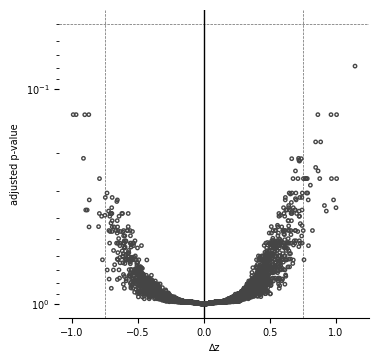

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Lipidomics


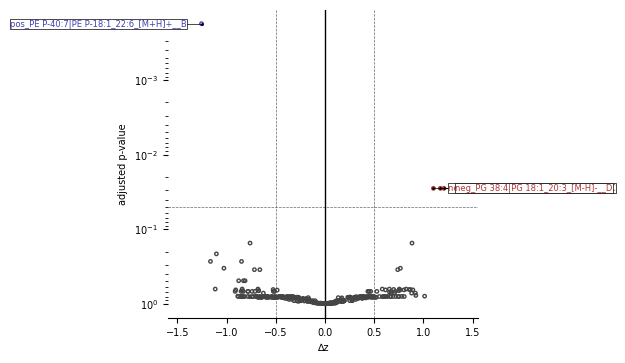

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-0.743886,1.123634,1.98482,-1.15378,-1.016881,-0.576549,-0.099197,-2.331863,-1.292387,1.34881,-0.186137,-0.045886,-1.638487,-0.045185,0.033684,1.650144,-1.008628,-0.733247,0.747037,1.10399,-0.738727,null,0.862671,-0.066471,-0.113485,0.522803,-0.931117,null,null,null,1.226205,null,null,null,null,null,…,null,null,null,null,0.504463,null,null,null,null,0.969242,0.340214,1.024657,1.540559,null,null,null,null,null,null,null,1.530025,null,null,null,null,null,null,0.575056,null,null,null,null,null,null,1.101566,0.000293,0.028325
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.041531,0.263501,2.084381,-1.331206,-1.075364,-0.450082,0.000525,-1.60006,-1.7418,1.128955,0.045585,0.443526,-1.805042,-0.540163,-0.487176,1.416679,-0.339389,-1.004379,-0.279032,0.795419,-1.031467,null,1.837889,-0.186379,-0.509573,0.127642,-0.73979,null,null,null,0.55845,null,null,null,null,null,…,null,null,null,null,0.003056,null,null,null,null,1.016435,0.720668,1.128402,1.305097,null,null,null,null,null,null,null,1.557361,null,null,null,null,null,null,1.382652,null,null,null,null,null,null,1.2085,0.000239,0.028325
"""neg_PG 38:4|PG 18:1_20:3_[M-H]…",-0.484233,0.309374,0.066456,-1.720113,-1.042972,-0.670214,0.91424,-2.040503,-1.427844,0.74338,0.598836,0.03627,-0.795926,-0.053888,1.127887,2.674081,-0.982645,-1.128586,0.193823,0.423688,-0.214842,null,1.056833,-0.568194,-1.009177,0.062533,-0.300948,null,null,null,1.05321,null,null,null,null,null,…,null,null,null,null,0.560329,null,null,null,null,1.672368,0.53405,0.333985,1.507322,null,null,null,null,null,null,null,1.29628,null,null,null,null,null,null,0.992774,null,null,null,null,null,null,1.17171,0.000331,0.028325


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""pos_PE P-40:7|PE P-18:1_22:6_[…",-1.032426,0.941353,-2.75009,0.823052,0.352766,0.134419,1.139432,0.500064,0.909051,-0.43227,1.005932,-0.003451,0.771744,-0.832616,-0.280181,0.268163,-0.018419,0.879454,-1.045738,0.628514,0.127306,null,0.897807,0.740314,3.23141,0.413738,1.346792,null,null,null,0.415851,null,null,null,null,null,…,null,null,null,null,-1.537864,null,null,null,null,-0.980427,-1.242626,-1.008769,-0.742584,null,null,null,null,null,null,null,-0.963853,null,null,null,null,null,null,null,null,null,null,null,null,null,-1.254384,5.1396e-7,0.000176


Metabolomics


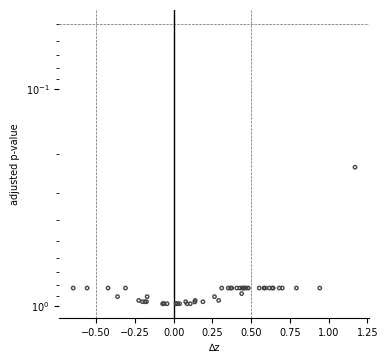

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


In [15]:
# key: (subset_id, block)
# value: {"up": top_n_up_df, "down": top_n_down_df}
top_up_and_down = {}

for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    print("============", subset_id, "============")
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Acetylomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        if (df := comps.get((subset_id, block))) is not None:
            print(block)
            top_up, top_down = plot_volcano_and_select_top_features(
                df,
                # use slightly less stringent criteria for the lipidomics and 
                # metabolomics data to get more significant features
                0.5 if block in ["Lipidomics", "Metabolomics"] else 0.75,   # effect size
                0.05,  # adjusted ttest p value
                subset_id,
                block
            )
            display(top_up)
            display(top_down)
            top_up_and_down[(subset_id, block)] = {"up": top_up, "down": top_down}

### Compare counts of selected features between black and white patients

#### NPM1

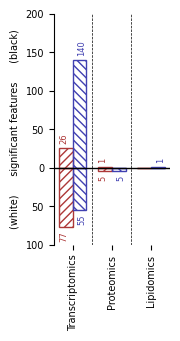

In [16]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITD

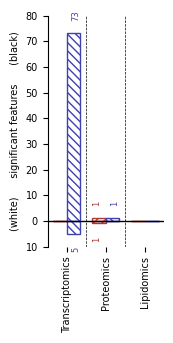

In [17]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITD-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITDxNPM1 vs. WT

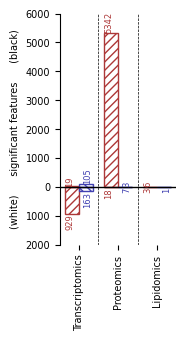

In [18]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITDxNPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()
